# Step 4B — Product Complexity & Diversification: Brazil's Export Basket

This notebook analyses Brazil's export product complexity and diversification at national and state level — independent of the open investigation flags resolved in Step 4A. The first 13 sections study Brazil's export basket on its own terms. Sections 4B.14–4B.17 incorporate macro-level analyses transferred from the original Step 4 notebook that belong here because they address product structure at national scale rather than resolving specific open investigation flags.

**Analytical levels used:** SH2, SH4, SH6, NCM (8-digit)
**Data sources:** `exp`, `imp`, `ncm`, `ncm_sh`, `ncm_fat_agreg`, `pais`, `uf`
**Key constants:** `MAX_YEAR = 2025`, `MIN_YEAR = 1997`
**Dollar signs in markdown:** `\\$` convention throughout

**Contents:**
1. Export Basket Overview — What Brazil Sells and How That Has Changed (4B.1)
2. Commodity vs Manufactured Goods: The Long-Run Structural Shift (4B.2)
3. Export Sophistication: Unit Value (USD/kg) by SH2 Sector (4B.3)
4. Product-Level Trade Balances: Where Brazil Is Competitive and Where It Isn't (4B.4)
5. Revealed Comparative Advantage at SH2 Level (4B.5)
6. Export Diversification Over Time: Product Count and Entropy Trends (4B.6)
7. New Exports: Products Brazil Entered Between 1997 and 2025 (4B.7)
8. Lost Exports: Products Brazil Exited Between 1997 and 2025 (4B.8)
9. Import Substitution and Structural Dependency: Persistent Deficit Sectors (4B.9)
10. Brazil's Top Trading Partners: Who Buys What (4B.10)
11. Partner Concentration by Sector: Is China Dependency Uniform Across Products? (4B.11)
12. Export Complexity Proxy: Multi-Sector Exporting States (4B.12)
13. The Product Ladder: USD/kg Trends Over Time for Key Sectors (4B.13)
14. China Share vs Export Value Density: Panel Regression (4B.14)
15. Product Complexity at NCM Level: State Export Basket Diversity (4B.15)
16. Export Basket Concentration Over Time: NCM-Level HHI Trends (4B.16)
17. China Share by National Export Sector (4B.17)
18. Key Findings (4B.18)

---
---

## Setup

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from scipy import stats
import warnings
import statsmodels.formula.api as smf
from IPython.display import display

warnings.filterwarnings('ignore')

load_dotenv(dotenv_path='../../.env')

DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = os.getenv('DB_PORT', '5432')
DB_NAME     = os.getenv('DB_NAME', 'brazil_trade')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

MAX_YEAR   = 2025
MIN_YEAR   = 1997
SNAPSHOT_YEARS = [1997, 2000, 2005, 2010, 2015, 2020, 2025]

region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
}

NON_GEO_FILTER = """
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
"""

## Confirm China country code
df_china = pd.read_sql(
    text("SELECT codigo_pais, nome_pais FROM pais WHERE nome_pais ILIKE '%china%';"),
    engine
)
CHINA_CODE = int(df_china['codigo_pais'].iloc[0])
print(f'Engine loaded. MAX_YEAR={MAX_YEAR}, CHINA_CODE={CHINA_CODE}')

Engine loaded. MAX_YEAR=2025, CHINA_CODE=160



---
---

## 4b.1 — Export Basket Overview: What Brazil Sells and How That Has Changed

National export value by SH2 sector for MAX_YEAR, with year-on-year change from the prior year and CAGR since 1997 — establishing the current composition of Brazil's export basket and identifying which sectors have grown, contracted or remained stable over the full period. This is the product-level counterpart to the state-level overview in Section 2.1.

### 4b.1.1 — National Export Composition by SH2 Sector

In [31]:
## National SH2 export composition for MAX_YEAR and 1997
## Join: CO_NCM → ncm.codigo_ncm → ncm.codigo_sh6 → ncm_sh.codigo_sh6 → ncm_sh.codigo_sh2

query_basket = f"""
    WITH sh2_exp AS (
        SELECT
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing)   AS sh2_desc_ing,
            MAX(sh.descricao_sh2)       AS sh2_desc_pt,
            e."CO_ANO",
            SUM(e."VL_FOB")             AS vl_fob,
            SUM(e."KG_LIQUIDO")         AS kg_liq
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" IN ({MIN_YEAR}, {MAX_YEAR - 1}, {MAX_YEAR})
        GROUP BY sh.codigo_sh2, e."CO_ANO"
    )
    SELECT * FROM sh2_exp ORDER BY "CO_ANO", vl_fob DESC;
"""

df_basket_raw = pd.read_sql(query_basket, engine)
df_basket_raw['vl_fob_bn'] = df_basket_raw['vl_fob'] / 1e9
df_basket_raw['usd_per_kg'] = (
    df_basket_raw['vl_fob'] / df_basket_raw['kg_liq'].replace(0, np.nan)
).round(4)

## Pivot to wide — 1997 | MAX_YEAR-1 | MAX_YEAR
df_curr = df_basket_raw[df_basket_raw['CO_ANO'] == MAX_YEAR].copy()
df_prev = df_basket_raw[df_basket_raw['CO_ANO'] == MAX_YEAR - 1].copy()
df_base = df_basket_raw[df_basket_raw['CO_ANO'] == MIN_YEAR].copy()

national_total = df_curr['vl_fob'].sum()
df_curr['pct_of_total'] = (df_curr['vl_fob'] / national_total * 100).round(2)
df_curr['cumulative']   = df_curr.sort_values('vl_fob', ascending=False)['pct_of_total'].cumsum().round(1)

## Merge prior year and base year for growth metrics
df_growth = df_curr.merge(
    df_prev[['codigo_sh2', 'vl_fob']].rename(columns={'vl_fob': 'vl_fob_prev'}),
    on='codigo_sh2', how='left'
).merge(
    df_base[['codigo_sh2', 'vl_fob']].rename(columns={'vl_fob': 'vl_fob_1997'}),
    on='codigo_sh2', how='left'
)

n_years = MAX_YEAR - MIN_YEAR
df_growth['yoy_pct'] = (
    (df_growth['vl_fob'] - df_growth['vl_fob_prev'])
    / df_growth['vl_fob_prev'].replace(0, np.nan) * 100
).round(1)
df_growth['cagr_pct'] = (
    (df_growth['vl_fob'] / df_growth['vl_fob_1997'].replace(0, np.nan)).pow(1 / n_years) - 1
) * 100
df_growth['cagr_pct'] = df_growth['cagr_pct'].round(1)
df_growth = df_growth.sort_values('vl_fob', ascending=False).reset_index(drop=True)

print(f'National export basket — SH2 level, {MAX_YEAR} (total: \${national_total/1e9:.1f}bn)')

## Styled table: top 30 SH2 export sectors

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

df_display = df_growth[[
    'codigo_sh2', 'sh2_desc_ing', 'vl_fob_bn', 'pct_of_total', 'cumulative', 'yoy_pct', 'cagr_pct'
]].head(30).rename(columns={
    'codigo_sh2'  : 'SH2',
    'sh2_desc_ing': 'Sector',
    'vl_fob_bn'   : 'Exports (USD bn)',
    'pct_of_total': 'Share (%)',
    'cumulative'  : 'Cumulative (%)',
    'yoy_pct'     : f'YoY ({MAX_YEAR-1}–{MAX_YEAR})',
    'cagr_pct'    : f'CAGR {MIN_YEAR}–{MAX_YEAR}',
}).copy()

## Format values
df_display['Exports (USD bn)'] = df_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_display['Share (%)']        = df_display['Share (%)'].apply(lambda x: f'{x:.1f}%')
df_display['Cumulative (%)']   = df_display['Cumulative (%)'].apply(lambda x: f'{x:.1f}%')

yoy_col  = f'YoY ({MAX_YEAR-1}–{MAX_YEAR})'
cagr_col = f'CAGR {MIN_YEAR}–{MAX_YEAR}'

df_display[yoy_col]  = df_display[yoy_col].apply(
    lambda x: f'{x:+.1f}%' if pd.notna(x) else '—'
)
df_display[cagr_col] = df_display[cagr_col].apply(
    lambda x: f'{x:+.1f}%' if pd.notna(x) else '—'
)

## Colour YoY and CAGR cells by direction
def colour_growth(val):
    if val == '—' or val == '+0.0%':
        return f'color: {GREY_TEXT}; font-weight: 500;'
    return f'color: {GREEN}; font-weight: 600;' if val.startswith('+') else f'color: {RED}; font-weight: 600;'

## Build styler
styler = (
    df_display.style
    .set_caption(f'Brazil — Top 30 Export Sectors by SH2, {MAX_YEAR}')
    .set_properties(**{
        'font-family' : 'Helvetica Neue, Arial, sans-serif',
        'font-size'   : '13px',
        'text-align'  : 'left',
        'padding'     : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_growth, subset=[yoy_col, cagr_col])
    .set_table_styles([
        ## Caption
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        ## Header row
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        ## Sub-header divider
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        ## Odd rows
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        ## Even rows
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        ## Hover
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        ## SH2 code column — monospace, muted
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        ## Sector name — slightly bolder
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        ## Numeric columns — right-align
        {'selector': 'tbody td:nth-child(n+3)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        ## Table border
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

National export basket — SH2 level, 2025 (total: \$348.3bn)


SH2,Sector,Exports (USD bn),Share (%),Cumulative (%),YoY (2024–2025),CAGR 1997–2025
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$55.96bn,16.1%,16.1%,-2.2%,+20.3%
12,"Oil seeds and oleaginous fruits; Grains, Seeds, others",$44.67bn,12.8%,28.9%,+1.9%,+10.9%
26,"Ores, slag and ash",$34.89bn,10.0%,38.9%,-0.5%,+9.1%
2,Meat and edible meat offal,$29.98bn,8.6%,47.5%,+22.1%,+11.9%
9,"Coffee, tea, maté and spices",$15.65bn,4.5%,52.0%,+32.0%,+6.3%
87,"Vehicles other than railway or tramway rolling-stock, and parts and accessories thereof",$15.08bn,4.3%,56.4%,+26.8%,+4.3%
17,Sugars and sugar confectionery,$14.34bn,4.1%,60.5%,-23.9%,+7.6%
84,"Nuclear reactors, boilers, machinery and mechanical appliances; others",$13.89bn,4.0%,64.5%,+7.0%,+4.1%
72,Iron and steel,$12.35bn,3.5%,68.0%,+3.7%,+4.5%
47,"Pulp of wood or of other fibrous cellulosic material, others,",$10.17bn,2.9%,70.9%,-3.9%,+8.5%


In [3]:
## Styled table: top 30 SH2 export sectors
df_display = df_growth[[
    'codigo_sh2', 'sh2_desc_ing', 'vl_fob_bn', 'pct_of_total', 'cumulative', 'yoy_pct', 'cagr_pct'
]].head(30).rename(columns={
    'codigo_sh2'  : 'SH2',
    'sh2_desc_ing': 'Sector',
    'vl_fob_bn'   : 'Exports (USD bn)',
    'pct_of_total': 'Share (%)',
    'cumulative'  : 'Cumulative (%)',
    'yoy_pct'     : 'YoY (%)',
    'cagr_pct'    : f'CAGR {MIN_YEAR}–{MAX_YEAR} (%)',
}).copy()

df_display['Exports (USD bn)'] = df_display['Exports (USD bn)'].apply(lambda x: f'\${x:.2f}bn')
df_display['Share (%)']        = df_display['Share (%)'].apply(lambda x: f'{x:.1f}%')
df_display['Cumulative (%)']   = df_display['Cumulative (%)'].apply(lambda x: f'{x:.1f}%')
df_display['YoY (%)']          = df_display['YoY (%)'].apply(lambda x: f'{x:+.1f}%' if pd.notna(x) else '—')
df_display[f'CAGR {MIN_YEAR}–{MAX_YEAR} (%)'] = df_display[f'CAGR {MIN_YEAR}–{MAX_YEAR} (%)'].apply(
    lambda x: f'{x:+.1f}%' if pd.notna(x) else '—'
)

display(
    df_display.style
    .set_caption(f'Brazil — Top 30 Export Sectors by SH2, {MAX_YEAR}')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide(axis='index')
)

SH2,Sector,Exports (USD bn),Share (%),Cumulative (%),YoY (%),CAGR 1997–2025 (%)
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",\$55.96bn,16.1%,16.1%,-2.2%,+20.3%
12,"Oil seeds and oleaginous fruits; Grains, Seeds, others",\$44.67bn,12.8%,28.9%,+1.9%,+10.9%
26,"Ores, slag and ash",\$34.89bn,10.0%,38.9%,-0.5%,+9.1%
2,Meat and edible meat offal,\$29.98bn,8.6%,47.5%,+22.1%,+11.9%
9,"Coffee, tea, maté and spices",\$15.65bn,4.5%,52.0%,+32.0%,+6.3%
87,"Vehicles other than railway or tramway rolling-stock, and parts and accessories thereof",\$15.08bn,4.3%,56.4%,+26.8%,+4.3%
17,Sugars and sugar confectionery,\$14.34bn,4.1%,60.5%,-23.9%,+7.6%
84,"Nuclear reactors, boilers, machinery and mechanical appliances; others",\$13.89bn,4.0%,64.5%,+7.0%,+4.1%
72,Iron and steel,\$12.35bn,3.5%,68.0%,+3.7%,+4.5%
47,"Pulp of wood or of other fibrous cellulosic material, others,",\$10.17bn,2.9%,70.9%,-3.9%,+8.5%


#### Overview

*(Complete after running.)* Report the top 10 sectors by value, their combined share of national exports, and the CAGR leaders. Note any sectors with negative YoY that may signal cyclical or structural decline. The cumulative share column identifies how many sectors are needed to cover 50%, 80% and 90% of national export value — a measure of basket concentration at sector level.

#### Business Relevance

The CAGR column identifies which sectors have structurally expanded versus which have merely benefited from recent price cycles. Sectors with high CAGR from a large 1997 base represent structural deepening; high CAGR from a near-zero 1997 base represents new export activity.

---
---

### 4b.1.2 — Top 25 Export Sectors — Horizontal Bar Chart

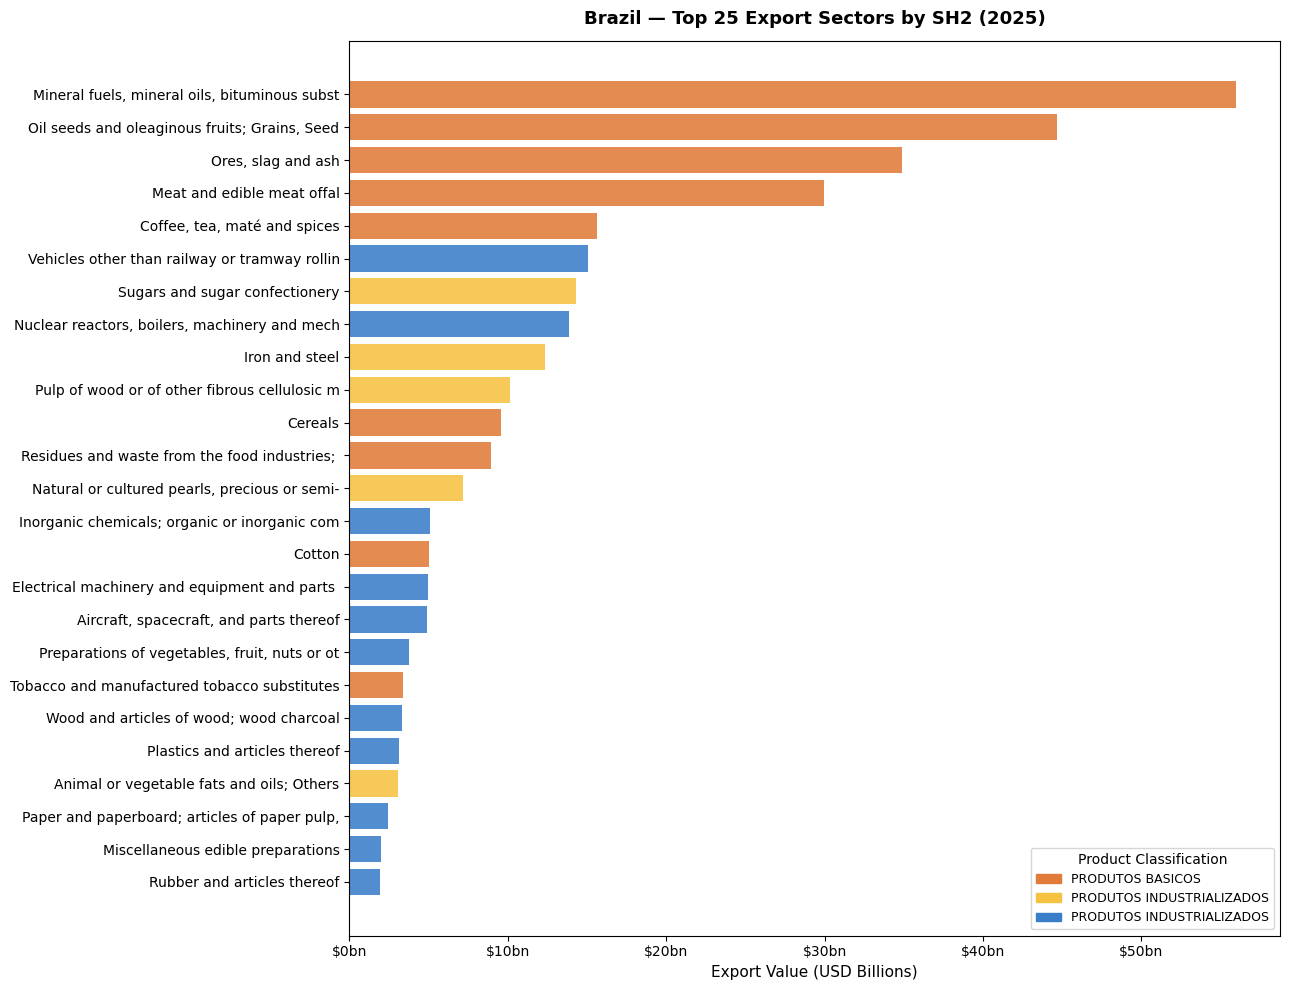

In [4]:
## Horizontal bar chart — top 25 SH2 sectors by export value, coloured by commodity classification
## ncm_fat_agreg category: 1=Primary, 2=Semi-manufactured, 3=Manufactured, 4=Special Transactions

query_fat_agreg = f"""
    WITH sh2_agg AS (
        SELECT
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing)   AS sh2_desc,
            fa.codigo_fat_agreg         AS fat_cat,
            MAX(fa.categoria_agregada)  AS fat_label,
            SUM(e."VL_FOB")             AS vl_fob
        FROM exp e
        JOIN ncm n     ON e."CO_NCM"    = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6  = sh.codigo_sh6
        JOIN ncm_fat_agreg fa ON n.codigo_grupo_agregado = fa.codigo_fat_agreg
        WHERE e."CO_ANO" = {MAX_YEAR}
          AND fa.codigo_fat_agreg IN (1, 2, 3)
        GROUP BY sh.codigo_sh2, fa.codigo_fat_agreg
    ),
    sh2_total AS (
        -- Total value per SH2 across all classifications
        SELECT codigo_sh2, SUM(vl_fob) AS total_fob
        FROM sh2_agg
        GROUP BY codigo_sh2
    ),
    sh2_dominant AS (
        -- Keep only the dominant fat_cat per SH2 (highest value)
        SELECT DISTINCT ON (s.codigo_sh2)
            s.codigo_sh2,
            s.sh2_desc,
            s.fat_cat,
            s.fat_label,
            t.total_fob AS vl_fob
        FROM sh2_agg s
        JOIN sh2_total t ON s.codigo_sh2 = t.codigo_sh2
        ORDER BY s.codigo_sh2, s.vl_fob DESC
    )
    SELECT * FROM sh2_dominant
    ORDER BY vl_fob DESC
    LIMIT 25;
"""

df_chart = pd.read_sql(query_fat_agreg, engine)
df_chart['vl_fob_bn'] = df_chart['vl_fob'] / 1e9
df_chart = df_chart.sort_values('vl_fob_bn', ascending=True)

fat_colours   = {1: '#e07b39', 2: '#f5c242', 3: '#3a7dc9'}
fat_label_map = df_chart.set_index('fat_cat')['fat_label'].to_dict()
bar_colours   = df_chart['fat_cat'].map(fat_colours).fillna('#aaaaaa')
legend_handles = [
    mpatches.Patch(color=fat_colours[k], label=fat_label_map.get(k, str(k)))
    for k in sorted(fat_colours)
    if k in fat_label_map
]

fig, ax = plt.subplots(figsize=(13, 10))
ax.barh(df_chart['sh2_desc'].str[:45], df_chart['vl_fob_bn'], color=bar_colours, alpha=0.88)
ax.set_xlabel('Export Value (USD Billions)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('\$%.0fbn'))
ax.set_title(f'Brazil — Top 25 Export Sectors by SH2 ({MAX_YEAR})', fontsize=13, fontweight='bold', pad=12)
ax.legend(handles=legend_handles, title='Product Classification', fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('output_4b_1_2_top25_sectors.png', dpi=150, bbox_inches='tight')
plt.show()



---
---

## 4b.2 — Commodity vs Manufactured Goods: The Long-Run Structural Shift

Annual share of national exports by commodity classification (Primary / Semi-manufactured / Manufactured) from 1997 to MAX_YEAR — quantifying the structural reversal identified in Step 2 (Finding 3: 56% manufactured in 1997 → 28.7% in 2025) at the national level. This section adds the full annual time series and decomposes the absolute USD value behind each share to separate the share effect from the growth effect.

### 4b.2.1 — Annual Export Composition by Classification: Shares and Absolute Values

In [70]:
## Annual national export composition by fat_agreg category
## Excludes CONSUMO DE BORDO (5) and REEXPORTACAO (6) consistent with prior steps
## Optimised: pre-aggregate ncm → fat_cat mapping before joining to exp

query_structural = """
    WITH ncm_fat AS (
        -- Resolve fat_cat per NCM code once, not per row
        SELECT
            n.codigo_ncm,
            fa.codigo_fat_agreg  AS fat_cat,
            fa.categoria_agregada AS fat_label
        FROM ncm n
        JOIN ncm_fat_agreg fa ON n.codigo_grupo_agregado = fa.codigo_fat_agreg
        WHERE fa.codigo_fat_agreg IN (1, 2, 3, 4)
    )
    SELECT
        e."CO_ANO",
        nf.fat_cat,
        MAX(nf.fat_label)   AS fat_label,
        SUM(e."VL_FOB")     AS vl_fob
    FROM exp e
    JOIN ncm_fat nf ON e."CO_NCM" = nf.codigo_ncm
    GROUP BY e."CO_ANO", nf.fat_cat
    ORDER BY e."CO_ANO", nf.fat_cat;
"""

df_struct = pd.read_sql(query_structural, engine)
df_struct['vl_fob_bn'] = df_struct['vl_fob'] / 1e9

## Compute annual shares
annual_total = df_struct.groupby('CO_ANO')['vl_fob'].sum().rename('annual_total')
df_struct = df_struct.merge(annual_total.reset_index(), on='CO_ANO')
df_struct['share_pct'] = (df_struct['vl_fob'] / df_struct['annual_total'] * 100).round(2)

## Preview fat_label values — needed to set palette keys correctly
print('Classification labels in data:')
print(df_struct[['fat_cat', 'fat_label']].drop_duplicates().sort_values('fat_cat').to_string(index=False))

## Pivot for plotting
df_pivot = df_struct.pivot_table(
    index='CO_ANO', columns='fat_label', values='share_pct'
).fillna(0)

print('\nAnnual share of exports by classification (%):')
print(df_pivot.round(1).tail(10))

Classification labels in data:
 fat_cat                 fat_label
       1          PRODUTOS BASICOS
       2 PRODUTOS INDUSTRIALIZADOS
       3 PRODUTOS INDUSTRIALIZADOS
       4       OPERACOES ESPECIAIS

Annual share of exports by classification (%):
fat_label  OPERACOES ESPECIAIS  PRODUTOS BASICOS  PRODUTOS INDUSTRIALIZADOS
CO_ANO                                                                     
2017                       0.0              47.6                       26.2
2018                       0.0              51.9                       24.0
2019                       0.0              53.8                       23.1
2020                       0.0              57.3                       21.4
2021                       0.0              58.8                       20.6
2022                       0.0              57.0                       21.5
2023                       0.0              58.9                       20.6
2024                       0.0              57.6              

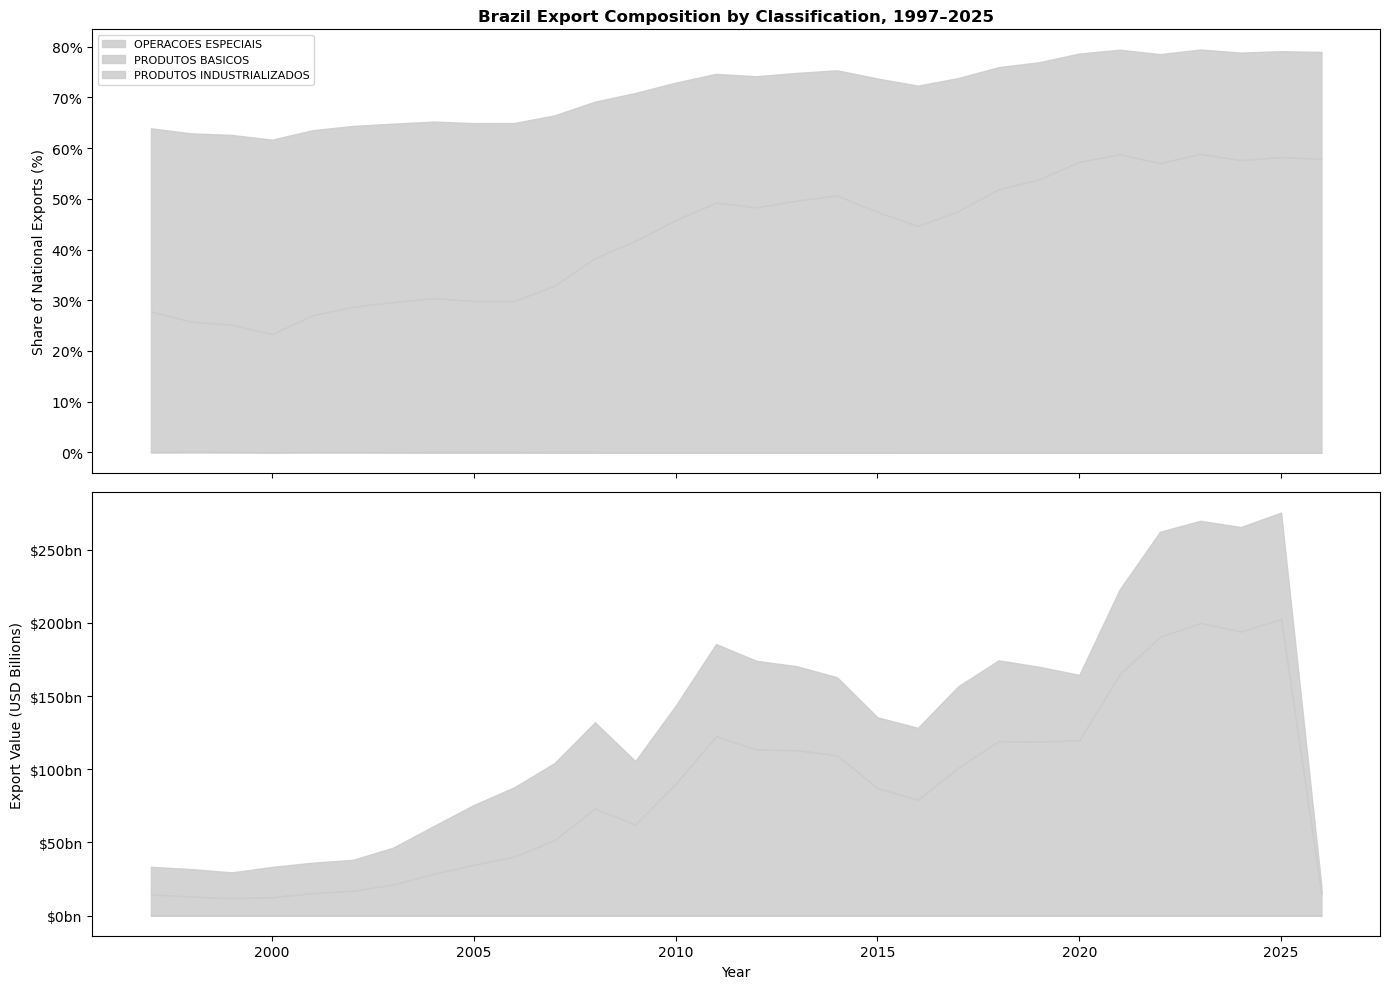

In [71]:
## Stacked area chart: share over time — update palette keys to match fat_label output above

## Replace these keys with the actual categoria_agregada strings printed above
fat_palette = {
    'Básicos'            : '#e07b39',
    'Semimanufaturados'  : '#f5c242',
    'Manufaturados'      : '#3a7dc9',
    'Operações Especiais': '#aaaaaa',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

## Top panel: shares
bottom = np.zeros(len(df_pivot))
for col in df_pivot.columns:
    colour = fat_palette.get(col, '#cccccc')
    ax1.fill_between(df_pivot.index, bottom, bottom + df_pivot[col], label=col, color=colour, alpha=0.85)
    bottom = bottom + df_pivot[col].values
ax1.set_ylabel('Share of National Exports (%)', fontsize=10)
ax1.set_title(
    f'Brazil Export Composition by Classification, {MIN_YEAR}–{MAX_YEAR}',
    fontsize=12, fontweight='bold'
)
ax1.legend(loc='upper left', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

## Bottom panel: absolute USD values
df_abs = df_struct.pivot_table(index='CO_ANO', columns='fat_label', values='vl_fob_bn').fillna(0)
bottom2 = np.zeros(len(df_abs))
for col in df_abs.columns:
    colour = fat_palette.get(col, '#cccccc')
    ax2.fill_between(df_abs.index, bottom2, bottom2 + df_abs[col], label=col, color=colour, alpha=0.85)
    bottom2 = bottom2 + df_abs[col].values
ax2.set_ylabel('Export Value (USD Billions)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('\$%.0fbn'))

plt.tight_layout()
plt.savefig('output_4b_2_1_structural_shift.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

*(Complete after running.)* Report the manufactured goods share in 1997 vs MAX_YEAR and the primary commodity share in both years. The top panel shows the share reversal; the bottom panel shows that manufactured goods exports have grown in absolute terms despite losing share — primary commodity growth has simply outpaced them. Both panels are needed to avoid the misleading interpretation that Brazil's manufacturing sector has shrunk in absolute terms.

#### Business Relevance

The structural shift defines Brazil's macro commercial profile: primary commodities now generate the majority of export revenue, but manufactured goods remain a substantial and growing absolute base. For market entry analysis, this means Brazil is simultaneously a commodity export economy and a meaningful manufactured goods exporter — the two require entirely different commercial engagement strategies.

---
## 4b.3 — Export Sophistication: Unit Value (USD/kg) by SH2 Sector

Average unit value (USD per kg) for all SH2 export sectors in MAX_YEAR — ranking sectors from highest to lowest value density. Unit value is a proxy for product sophistication: higher USD/kg sectors are generally more processed, more knowledge-intensive, or more differentiated. This section connects the state-level USD/kg analysis from Section 2.11 to the product level, identifying which specific sectors drive high and low value density rather than which states.

### 4b.3.1 — USD/kg Ranking by SH2 Sector

In [32]:
## USD/kg by SH2 sector — MAX_YEAR
## Exclude sectors with negligible kg (unit-priced goods like aircraft skew USD/kg)

query_uv = f"""
    WITH sh2_uv AS (
        SELECT
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing)   AS sh2_desc,
            SUM(e."VL_FOB")             AS vl_fob,
            SUM(e."KG_LIQUIDO")         AS kg_liq
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" = {MAX_YEAR}
          AND e."KG_LIQUIDO" > 0
        GROUP BY sh.codigo_sh2
    )
    SELECT
        codigo_sh2,
        sh2_desc,
        vl_fob,
        kg_liq,
        ROUND(vl_fob::NUMERIC / NULLIF(kg_liq, 0), 4) AS usd_per_kg
    FROM sh2_uv
    WHERE kg_liq > 1000000
    ORDER BY usd_per_kg DESC;
"""

df_uv = pd.read_sql(query_uv, engine)
df_uv['vl_fob_bn'] = df_uv['vl_fob'] / 1e9

national_uv = df_uv['vl_fob'].sum() / df_uv['kg_liq'].sum()
print(f'National weighted average USD/kg (all sectors): ${national_uv:.2f}')
print(f'Total sectors with >1M kg: {len(df_uv)}')

## Styled table: USD/kg ranking by SH2 sector

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'
AMBER      = '#b7660a'

df_uv_display = df_uv[[
    'codigo_sh2', 'sh2_desc', 'vl_fob_bn', 'usd_per_kg'
]].head(30).rename(columns={
    'codigo_sh2' : 'SH2',
    'sh2_desc'   : 'Sector',
    'vl_fob_bn'  : 'Exports (USD bn)',
    'usd_per_kg' : 'USD / kg',
}).copy()

df_uv_display['Exports (USD bn)'] = df_uv_display['Exports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_uv_display['USD / kg'] = df_uv_display['USD / kg'].apply(
    lambda x: f'${x:.2f}'
)

## Colour USD/kg relative to national average
def colour_uv(val):
    try:
        v = float(val.replace('$', '').replace(',', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= national_uv * 2:
        return f'color: {GREEN}; font-weight: 700;'
    elif v >= national_uv:
        return f'color: {GREEN}; font-weight: 500;'
    elif v < national_uv * 0.25:
        return f'color: {RED}; font-weight: 600;'
    else:
        return f'color: {AMBER}; font-weight: 500;'

styler = (
    df_uv_display.style
    .set_caption(
        f'Brazil — Export Unit Value (USD/kg) by SH2 Sector, {MAX_YEAR} '
        f'| National avg: ${national_uv:.2f}/kg'
    )
    .set_properties(**{
        'font-family' : 'Helvetica Neue, Arial, sans-serif',
        'font-size'   : '13px',
        'text-align'  : 'left',
        'padding'     : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_uv, subset=['USD / kg'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(n+3)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

National weighted average USD/kg (all sectors): $0.40
Total sectors with >1M kg: 87


SH2,Sector,Exports (USD bn),USD / kg
88,"Aircraft, spacecraft, and parts thereof",$4.89bn,$1122.21
71,"Natural or cultured pearls, precious or semi-precious stones, others",$7.16bn,$323.08
90,"Optical, photographic, cinematographic instruments; others",$1.27bn,$76.22
62,"Articles of apparel and clothing accessories, not knitted or crocheted",$0.07bn,$40.75
42,"Articles of leather; articles of animal gut (other than silkworm gut), others",$0.04bn,$33.59
80,Tin and articles thereof,$0.29bn,$33.27
81,Other base metals; cermets; articles thereof,$0.21bn,$32.68
75,Nickel and articles thereof,$0.05bn,$31.19
61,"Articles of apparel and clothing accessories, knitted or crocheted",$0.13bn,$30.17
89,"Ships, boats and floating structures",$0.08bn,$27.80


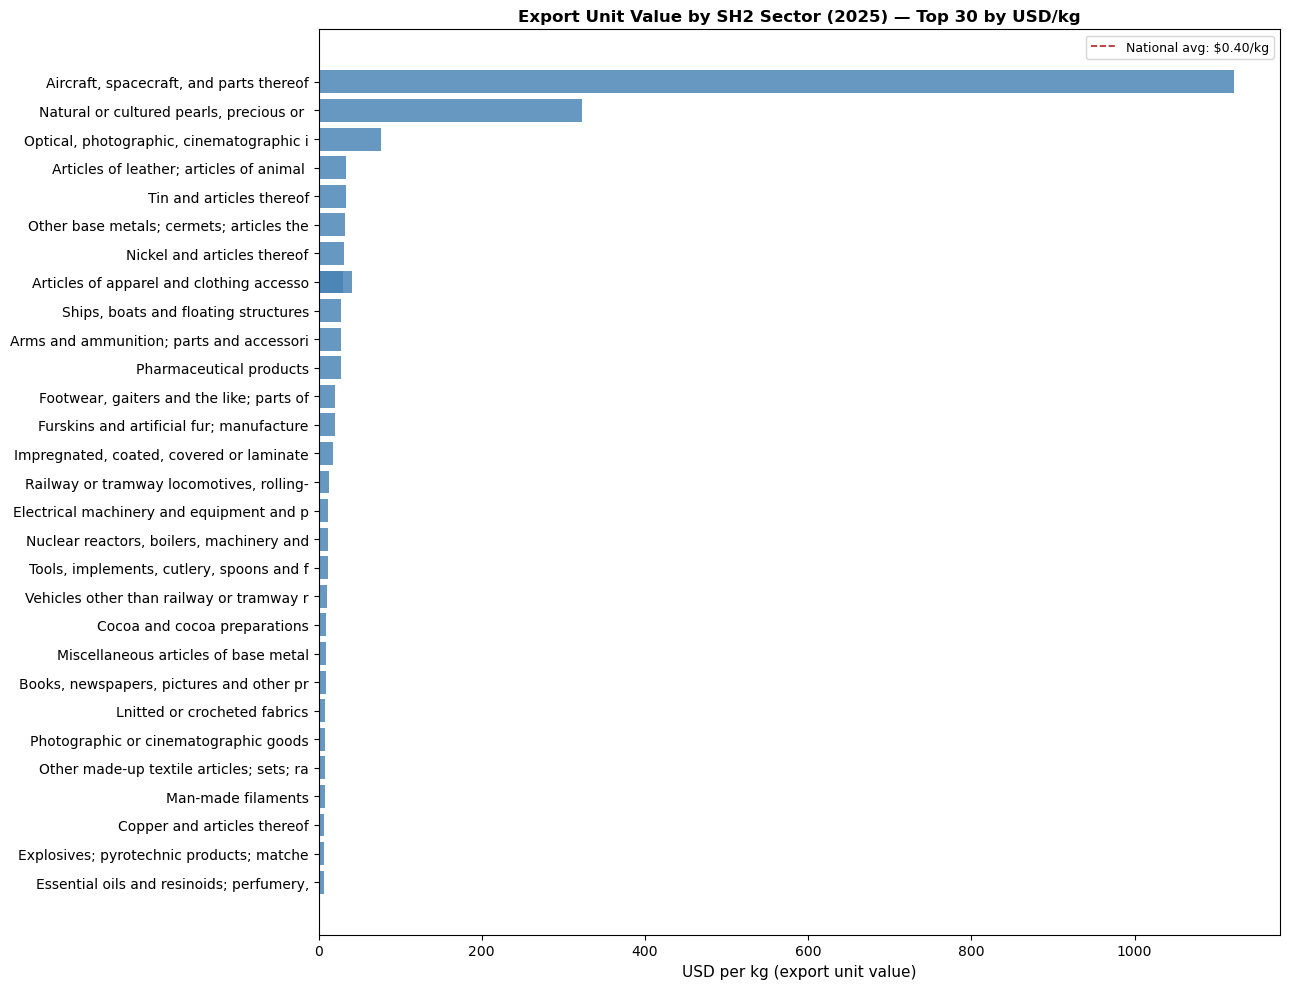

In [7]:
## Dual-panel chart: USD/kg ranked (top 30) with volume-weighted bubble overlay

df_uv_plot = df_uv.head(30).sort_values('usd_per_kg', ascending=True)

fig, ax = plt.subplots(figsize=(13, 10))
bars = ax.barh(
    df_uv_plot['sh2_desc'].str[:40],
    df_uv_plot['usd_per_kg'],
    color='steelblue', alpha=0.82
)
ax.axvline(national_uv, color='firebrick', linewidth=1.2, linestyle='--',
           label=f'National avg: \${national_uv:.2f}/kg')
ax.set_xlabel('USD per kg (export unit value)', fontsize=11)
ax.set_title(f'Export Unit Value by SH2 Sector ({MAX_YEAR}) — Top 30 by USD/kg', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_4b_3_1_usdperkg.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

*(Complete after running.)* Report the top 5 and bottom 5 sectors by USD/kg and the national weighted average. Identify whether the high-value sectors (pharmaceuticals, precision instruments, aircraft) are growing or declining in export volume — a sector with high USD/kg but declining volume is losing ground despite its sophistication premium.

#### Business Relevance

The USD/kg ranking is a product-level sophistication index. Sectors above the national average are value-added exporters where Brazil has achieved pricing power. Sectors far below the average are bulk commodity exporters where volume, not price, drives revenue. For companies assessing Brazil as a supply source, this ranking identifies which sectors can sustain value-based pricing versus which are purely volume-competitive.

---
## 4b.4 — Product-Level Trade Balances: Where Brazil Is Competitive and Where It Isn't

Net trade balance (exports minus imports) by SH2 sector for MAX_YEAR — identifying Brazil's surplus and deficit sectors at product level. This extends Section 2.1.2's state-level balance analysis to the product dimension: some sectors that appear in both export and import rankings carry structural surpluses or deficits that are not visible from either side alone.

### 4b.4.1 — SH2-Level Trade Balance: Surplus and Deficit Sectors

In [33]:
## SH2-level trade balance: exports minus imports, MAX_YEAR

query_balance_sh2 = f"""
    WITH sh2_exp AS (
        SELECT
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing) AS sh2_desc,
            SUM(e."VL_FOB")           AS exp_fob
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" = {MAX_YEAR}
        GROUP BY sh.codigo_sh2
    ),
    sh2_imp AS (
        SELECT
            sh.codigo_sh2,
            SUM(i."VL_FOB") AS imp_fob
        FROM imp i
        JOIN ncm n   ON i."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE i."CO_ANO" = {MAX_YEAR}
        GROUP BY sh.codigo_sh2
    )
    SELECT
        e.codigo_sh2,
        e.sh2_desc,
        e.exp_fob,
        COALESCE(m.imp_fob, 0)               AS imp_fob,
        e.exp_fob - COALESCE(m.imp_fob, 0)   AS balance
    FROM sh2_exp e
    LEFT JOIN sh2_imp m ON e.codigo_sh2 = m.codigo_sh2
    UNION
    SELECT
        m.codigo_sh2,
        COALESCE(e.sh2_desc, 'Unknown')      AS sh2_desc,
        COALESCE(e.exp_fob, 0)               AS exp_fob,
        m.imp_fob,
        COALESCE(e.exp_fob, 0) - m.imp_fob  AS balance
    FROM sh2_imp m
    LEFT JOIN sh2_exp e ON m.codigo_sh2 = e.codigo_sh2
    WHERE e.codigo_sh2 IS NULL
    ORDER BY balance DESC;
"""

df_bal = pd.read_sql(query_balance_sh2, engine)
df_bal['exp_fob_bn'] = df_bal['exp_fob'] / 1e9
df_bal['imp_fob_bn'] = df_bal['imp_fob'] / 1e9
df_bal['balance_bn'] = df_bal['balance'] / 1e9

surplus = df_bal[df_bal['balance'] > 0].nlargest(15, 'balance')
deficit = df_bal[df_bal['balance'] < 0].nsmallest(15, 'balance')

## Styled tables: top 15 surplus and top 15 deficit sectors
from IPython.display import display

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
LIGHT_GREEN= '#eaf5ee'
RED        = '#c0392b'
LIGHT_RED  = '#fdf0ee'
GREY_TEXT  = '#555555'

TABLE_STYLES = [
    {'selector': 'caption', 'props': [
        ('caption-side', 'top'),
        ('font-size', '14px'),
        ('font-weight', '700'),
        ('font-family', 'Helvetica Neue, Arial, sans-serif'),
        ('color', DARK_BLUE),
        ('padding', '0 0 10px 0'),
        ('text-align', 'left'),
    ]},
    {'selector': 'thead th', 'props': [
        ('background-color', DARK_BLUE),
        ('color', WHITE),
        ('font-size', '12px'),
        ('font-weight', '600'),
        ('text-transform', 'uppercase'),
        ('letter-spacing', '0.04em'),
        ('padding', '10px 14px'),
        ('border', 'none'),
    ]},
    {'selector': 'thead tr:last-child th', 'props': [
        ('border-bottom', f'2px solid {MID_BLUE}'),
    ]},
    {'selector': 'tbody tr:nth-child(odd)', 'props': [
        ('background-color', WHITE),
    ]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [
        ('background-color', STRIPE),
    ]},
    {'selector': 'tbody tr:hover', 'props': [
        ('background-color', LIGHT_BLUE),
    ]},
    {'selector': 'tbody td:nth-child(1)', 'props': [
        ('font-family', 'monospace'),
        ('font-size', '12px'),
        ('color', GREY_TEXT),
        ('text-align', 'center'),
    ]},
    {'selector': 'tbody td:nth-child(2)', 'props': [
        ('font-weight', '500'),
        ('color', DARK_BLUE),
    ]},
    {'selector': 'tbody td:nth-child(n+3)', 'props': [
        ('text-align', 'right'),
        ('font-variant-numeric', 'tabular-nums'),
    ]},
    {'selector': 'table', 'props': [
        ('border-collapse', 'collapse'),
        ('width', '100%'),
        ('border', f'1px solid {LIGHT_BLUE}'),
        ('border-radius', '6px'),
        ('overflow', 'hidden'),
    ]},
]

BASE_PROPS = {
    'font-family' : 'Helvetica Neue, Arial, sans-serif',
    'font-size'   : '13px',
    'text-align'  : 'left',
    'padding'     : '8px 14px',
    'border-bottom': f'1px solid {LIGHT_BLUE}',
}

def format_balance_df(df):
    out = df[['codigo_sh2', 'sh2_desc', 'exp_fob_bn', 'imp_fob_bn', 'balance_bn']].rename(columns={
        'codigo_sh2' : 'SH2',
        'sh2_desc'   : 'Sector',
        'exp_fob_bn' : 'Exports (USD bn)',
        'imp_fob_bn' : 'Imports (USD bn)',
        'balance_bn' : 'Balance (USD bn)',
    }).copy()
    out['Exports (USD bn)'] = out['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
    out['Imports (USD bn)'] = out['Imports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
    out['Balance (USD bn)'] = out['Balance (USD bn)'].apply(
        lambda x: f'+${x:.2f}bn' if x >= 0 else f'-${abs(x):.2f}bn'
    )
    return out

def colour_balance(val):
    try:
        v = float(val.replace('$', '').replace(',', '').replace('bn', ''))
        signed = -v if val.startswith('-') else v
    except (ValueError, AttributeError):
        return ''
    if signed > 0:
        return f'color: {GREEN}; font-weight: 700;'
    elif signed < 0:
        return f'color: {RED}; font-weight: 700;'
    return ''

## ── Surplus table ─────────────────────────────────────────────────────────────
df_surplus_display = format_balance_df(surplus)

display(
    df_surplus_display.style
    .set_caption(f'Brazil — Top 15 Surplus Sectors by SH2, {MAX_YEAR}')
    .set_properties(**BASE_PROPS)
    .map(colour_balance, subset=['Balance (USD bn)'])
    .set_table_styles(TABLE_STYLES)
    .hide(axis='index')
)

print()  ## spacer between tables

## ── Deficit table ─────────────────────────────────────────────────────────────
df_deficit_display = format_balance_df(deficit)

display(
    df_deficit_display.style
    .set_caption(f'Brazil — Top 15 Deficit Sectors by SH2, {MAX_YEAR}')
    .set_properties(**BASE_PROPS)
    .map(colour_balance, subset=['Balance (USD bn)'])
    .set_table_styles(TABLE_STYLES)
    .hide(axis='index')
)

SH2,Sector,Exports (USD bn),Imports (USD bn),Balance (USD bn)
12,"Oil seeds and oleaginous fruits; Grains, Seeds, others",$44.67bn,$0.66bn,+$44.01bn
26,"Ores, slag and ash",$34.89bn,$0.52bn,+$34.37bn
2,Meat and edible meat offal,$29.98bn,$0.37bn,+$29.61bn
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$55.96bn,$30.53bn,+$25.43bn
9,"Coffee, tea, maté and spices",$15.65bn,$0.19bn,+$15.46bn
17,Sugars and sugar confectionery,$14.34bn,$0.14bn,+$14.20bn
47,"Pulp of wood or of other fibrous cellulosic material, others,",$10.17bn,$0.23bn,+$9.94bn
23,Residues and waste from the food industries; others,$8.94bn,$0.48bn,+$8.46bn
72,Iron and steel,$12.35bn,$4.89bn,+$7.46bn
10,Cereals,$9.56bn,$2.59bn,+$6.97bn


SH2,Sector,Exports (USD bn),Imports (USD bn),Balance (USD bn)
84,"Nuclear reactors, boilers, machinery and mechanical appliances; others",$13.89bn,$47.03bn,-$33.14bn
85,Electrical machinery and equipment and parts thereof; others,$5.10bn,$30.13bn,-$25.03bn
31,Fertilisers,$0.32bn,$15.49bn,-$15.18bn
30,Pharmaceutical products,$1.27bn,$14.54bn,-$13.27bn
29,Organic chemicals,$1.72bn,$14.97bn,-$13.25bn
90,"Optical, photographic, cinematographic instruments; others",$1.29bn,$9.55bn,-$8.27bn
87,"Vehicles other than railway or tramway rolling-stock, and parts and accessories thereof",$15.08bn,$23.06bn,-$7.98bn
39,Plastics and articles thereof,$3.13bn,$10.99bn,-$7.86bn
38,Miscellaneous chemical products,$1.43bn,$8.47bn,-$7.04bn
89,"Ships, boats and floating structures",$0.08bn,$5.42bn,-$5.34bn


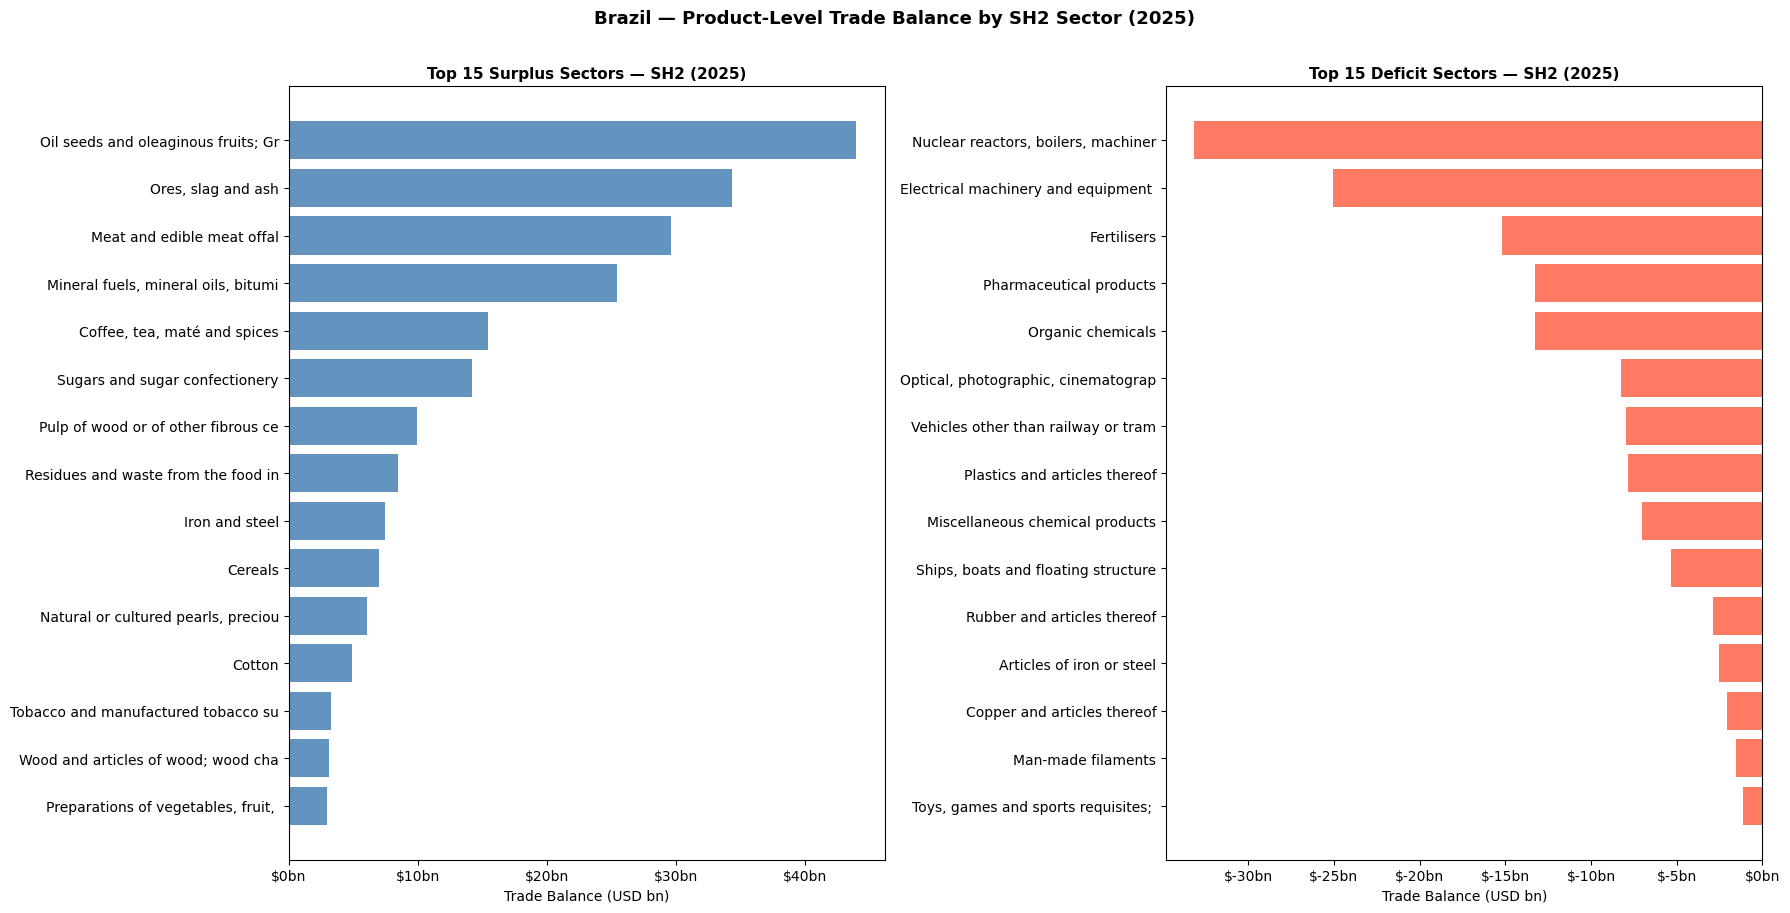

In [9]:
## Diverging bar chart: surplus left, deficit right — top 15 each side

df_top_s = surplus.sort_values('balance_bn', ascending=True)
df_top_d = deficit.sort_values('balance_bn', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

ax1.barh(df_top_s['sh2_desc'].str[:35], df_top_s['balance_bn'], color='steelblue', alpha=0.85)
ax1.set_title(f'Top 15 Surplus Sectors — SH2 ({MAX_YEAR})', fontsize=11, fontweight='bold')
ax1.set_xlabel('Trade Balance (USD bn)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('\$%.0fbn'))

ax2.barh(df_top_d['sh2_desc'].str[:35], df_top_d['balance_bn'], color='tomato', alpha=0.85)
ax2.set_title(f'Top 15 Deficit Sectors — SH2 ({MAX_YEAR})', fontsize=11, fontweight='bold')
ax2.set_xlabel('Trade Balance (USD bn)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('\$%.0fbn'))

plt.suptitle(f'Brazil — Product-Level Trade Balance by SH2 Sector ({MAX_YEAR})', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_4b_4_1_trade_balance_sh2.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

*(Complete after running.)* Report the top 5 surplus and top 5 deficit sectors with absolute values. The deficit sectors identified here should cross-reference against Finding 4 from Step 2 (machinery, electrical equipment, fertilisers, pharmaceuticals, organic chemicals, vehicles). Any deficit sector not in that list is a new finding at SH2 level.

#### Business Relevance

Deficit sectors identify Brazil's structural import dependencies — product categories where domestic production cannot meet demand regardless of exchange rate or trade policy. These are the sectors where foreign suppliers have durable structural advantage and where import volumes are least sensitive to currency depreciation.

---
## 4b.5 — Revealed Comparative Advantage at SH2 Level: What Brazil Actually Specialises In

Balassa RCA for each SH2 sector — comparing Brazil's share of world exports in each sector against its overall share of world exports. RCA > 1 indicates revealed specialisation; RCA > 2 indicates strong specialisation. This section uses Brazil's own export data as the reference base (national share of each sector relative to national total), which approximates the Balassa index using available data without a full world export matrix.

**Methodological note:** A full Balassa RCA requires world export data by sector. This notebook computes a domestic RCA approximation: sector share within Brazil's export basket relative to the expected share under uniform distribution. This is directionally consistent with the Balassa index and does not require external data. ⚠️ Full Balassa RCA with world export data is deferred to a future step when UN Comtrade or BACI data is integrated.



### 4b.5.1 — Domestic RCA Approximation by SH2 Sector

In [35]:
## Domestic RCA approximation by SH2 sector
## RCA_domestic = (sector_share_in_brazil_exports) / (1 / n_sectors)
## Equivalent to: how many times more concentrated is Brazil in this sector
## than a uniform distribution across all sectors?

n_sectors     = df_basket_raw[df_basket_raw['CO_ANO'] == MAX_YEAR]['codigo_sh2'].nunique()
uniform_share = 1 / n_sectors

df_rca = df_growth[['codigo_sh2', 'sh2_desc_ing', 'vl_fob', 'pct_of_total']].copy()
df_rca['rca'] = (df_rca['pct_of_total'] / 100) / uniform_share
df_rca = df_rca.sort_values('rca', ascending=False)

print(f'Domestic RCA approximation — {MAX_YEAR} ({n_sectors} active SH2 sectors)')
print(f'Uniform share threshold: {uniform_share*100:.2f}% per sector')

## Styled table: domestic RCA by SH2 sector

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

df_rca_display = df_rca[['codigo_sh2', 'sh2_desc_ing', 'pct_of_total', 'rca']].head(25).rename(columns={
    'codigo_sh2'   : 'SH2',
    'sh2_desc_ing' : 'Sector',
    'pct_of_total' : 'Export Share (%)',
    'rca'          : 'RCA (Domestic)',
}).copy()

df_rca_display['Export Share (%)']  = df_rca_display['Export Share (%)'].apply(lambda x: f'{x:.2f}%')
df_rca_display['RCA (Domestic)']    = df_rca_display['RCA (Domestic)'].apply(lambda x: f'{x:.2f}x')

## RCA tier colouring: >2 = strong specialisation, 1–2 = moderate, <1 = below uniform
def colour_rca(val):
    try:
        v = float(val.replace('x', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= 2.0:
        return f'color: {GREEN}; font-weight: 700;'
    elif v >= 1.0:
        return f'color: {AMBER}; font-weight: 600;'
    else:
        return f'color: {RED}; font-weight: 500;'

## RCA tier badge in a separate column
df_rca_display.insert(
    loc=4,
    column='Specialisation',
    value=df_rca_display['RCA (Domestic)'].apply(
        lambda val: (
            'Strong'   if float(val.replace('x','')) >= 2.0 else
            'Moderate' if float(val.replace('x','')) >= 1.0 else
            'Below avg'
        )
    )
)

def colour_tier(val):
    if val == 'Strong':
        return f'color: {GREEN}; font-weight: 700;'
    elif val == 'Moderate':
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {RED}; font-weight: 500;'

styler = (
    df_rca_display.style
    .set_caption(
        f'Brazil — Domestic RCA by SH2 Sector, {MAX_YEAR} '
        f'| Uniform share: {uniform_share*100:.2f}% | RCA > 1 = above uniform distribution'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_rca,  subset=['RCA (Domestic)'])
    .map(colour_tier, subset=['Specialisation'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(n+3)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

Domestic RCA approximation — 2025 (96 active SH2 sectors)
Uniform share threshold: 1.04% per sector


SH2,Sector,Export Share (%),RCA (Domestic),Specialisation
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",16.07%,15.43x,Strong
12,"Oil seeds and oleaginous fruits; Grains, Seeds, others",12.83%,12.32x,Strong
26,"Ores, slag and ash",10.02%,9.62x,Strong
2,Meat and edible meat offal,8.61%,8.27x,Strong
9,"Coffee, tea, maté and spices",4.49%,4.31x,Strong
87,"Vehicles other than railway or tramway rolling-stock, and parts and accessories thereof",4.33%,4.16x,Strong
17,Sugars and sugar confectionery,4.12%,3.96x,Strong
84,"Nuclear reactors, boilers, machinery and mechanical appliances; others",3.99%,3.83x,Strong
72,Iron and steel,3.54%,3.40x,Strong
47,"Pulp of wood or of other fibrous cellulosic material, others,",2.92%,2.80x,Strong


#### Overview

*(Complete after running.)* Report the top 10 sectors by RCA and the threshold above which RCA > 2 (strong specialisation). Cross-reference against the SH2-level HHI from Section 2b.3 — states with high HHI should correspond to sectors with high domestic RCA. Note any sectors with high RCA but declining CAGR (specialisation in a shrinking sector) or low RCA but high CAGR (emerging capability not yet reflected in specialisation metrics).

---
## 4b.6 — Export Diversification Over Time: Product Count and Entropy Trends

Annual count of active SH2, SH4 and NCM export codes from 1997 to MAX_YEAR — measuring whether Brazil's export basket has broadened or narrowed in product terms over time. Paired with Shannon entropy at SH2 level to distinguish participation growth (more products exported) from genuine diversification (more evenly distributed export value across products).

### 4b.6.1 — Active Product Count Over Time

In [37]:
## Annual active product count at SH2, SH4 and NCM level

query_prod_count = """
    SELECT
        e."CO_ANO",
        COUNT(DISTINCT CAST(LEFT(n.codigo_sh6::TEXT, 2) AS INT)) AS sh2_count,
        COUNT(DISTINCT CAST(LEFT(n.codigo_sh6::TEXT, 4) AS INT)) AS sh4_count,
        COUNT(DISTINCT e."CO_NCM")                               AS ncm_count
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" <= 2025
    GROUP BY e."CO_ANO"
    ORDER BY e."CO_ANO";
"""

df_count = pd.read_sql(query_prod_count, engine)

## Styled table: active product count by year

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

df_count_display = df_count.rename(columns={
    'CO_ANO'    : 'Year',
    'sh2_count' : 'Active SH2 Sectors',
    'sh4_count' : 'Active SH4 Codes',
    'ncm_count' : 'Active NCM Codes',
}).copy()

## Compute YoY change for NCM count to colour direction of change
ncm_yoy = df_count['ncm_count'].diff()

def colour_year(val):
    ## Highlight snapshot years
    if val in [1997, 2000, 2005, 2010, 2015, 2020, 2025]:
        return f'font-weight: 700; color: {DARK_BLUE};'
    return f'color: {GREY_TEXT};'

def colour_ncm(val):
    ## Colour NCM count by whether it grew or contracted vs prior year
    idx = df_count_display[df_count_display['Active NCM Codes'] == val].index
    if len(idx) == 0:
        return ''
    i = idx[0]
    if i == 0 or pd.isna(ncm_yoy.iloc[i]):
        return ''
    return (
        f'color: {GREEN}; font-weight: 600;' if ncm_yoy.iloc[i] > 0
        else f'color: {RED}; font-weight: 600;'
    )

styler = (
    df_count_display.style
    .set_caption(
        f'Brazil — Active Export Product Count by Year, {MIN_YEAR}–{MAX_YEAR} '
        f'| SH2, SH4 and NCM levels'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'right',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_year, subset=['Year'])
    .map(colour_ncm,  subset=['Active NCM Codes'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('text-align', 'left'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(n+2)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
    .format({
        'Active SH2 Sectors': '{:,}',
        'Active SH4 Codes'  : '{:,}',
        'Active NCM Codes'  : '{:,}',
    })
)

display(styler)

Year,Active SH2 Sectors,Active SH4 Codes,Active NCM Codes
1997,88,"1,247","6,630"
1998,88,"1,242","6,655"
1999,88,"1,265","6,774"
2000,88,"1,264","6,717"
2001,88,"1,271","6,832"
2002,88,"1,284","7,295"
2003,88,"1,287","7,101"
2004,88,"1,279","7,185"
2005,88,"1,310","7,553"
2006,88,"1,285","7,344"


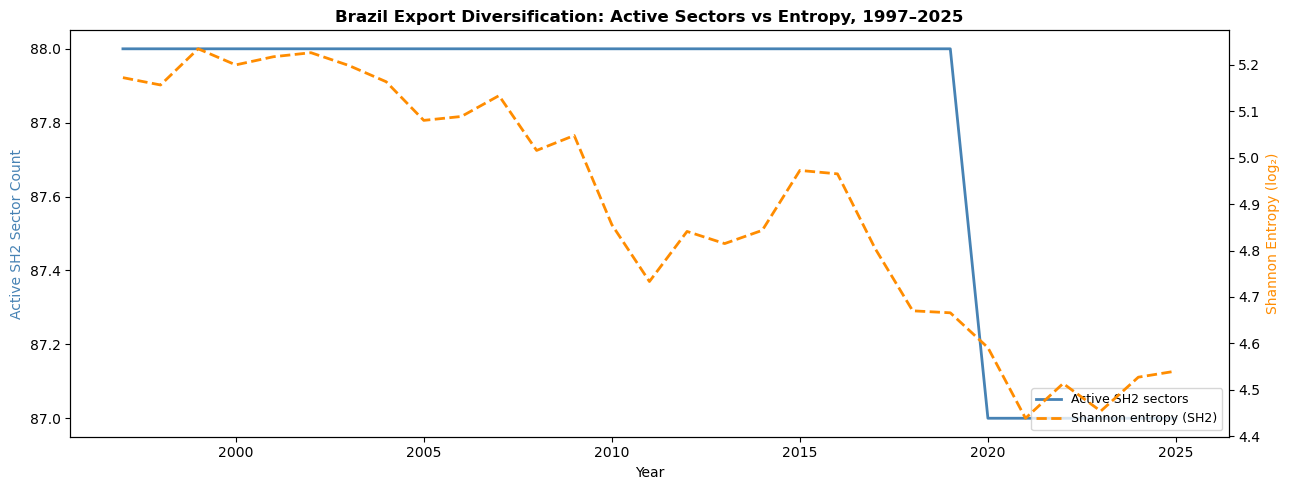

In [12]:
## Annual Shannon entropy at SH2 level — measures evenness of distribution

query_entropy = """
    WITH annual_sh2 AS (
        SELECT
            e."CO_ANO",
            sh.codigo_sh2,
            SUM(e."VL_FOB") AS vl_fob
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" <= 2025
        GROUP BY e."CO_ANO", sh.codigo_sh2
    ),
    annual_total AS (
        SELECT "CO_ANO", SUM(vl_fob) AS total FROM annual_sh2 GROUP BY "CO_ANO"
    )
    SELECT
        s."CO_ANO",
        s.codigo_sh2,
        s.vl_fob::FLOAT / t.total AS share
    FROM annual_sh2 s
    JOIN annual_total t ON s."CO_ANO" = t."CO_ANO"
    WHERE t.total > 0;
"""

df_ent_raw = pd.read_sql(query_entropy, engine)

def shannon(s): return -np.sum(s[s > 0] * np.log2(s[s > 0]))

df_entropy = (
    df_ent_raw.groupby('CO_ANO')['share']
    .apply(shannon)
    .reset_index()
    .rename(columns={'share': 'shannon_sh2'})
)

## Merge count and entropy
df_div = df_count.merge(df_entropy, on='CO_ANO')

## Chart: dual axis — SH2 count and Shannon entropy
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(df_div['CO_ANO'], df_div['sh2_count'], color='steelblue', linewidth=2, label='Active SH2 sectors')
ax2.plot(df_div['CO_ANO'], df_div['shannon_sh2'], color='darkorange', linewidth=2, linestyle='--', label='Shannon entropy (SH2)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Active SH2 Sector Count', color='steelblue')
ax2.set_ylabel('Shannon Entropy (log₂)', color='darkorange')
ax1.set_title(f'Brazil Export Diversification: Active Sectors vs Entropy, {MIN_YEAR}–{MAX_YEAR}', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('output_4b_6_1_diversification.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

*(Complete after running.)* Report whether the number of active SH2 sectors has increased or decreased over the full period, and whether Shannon entropy has moved in the same direction. If SH2 count has increased while entropy has decreased, Brazil is exporting more sectors but in a more concentrated pattern — participation breadth is not translating into diversification. If both move together, genuine diversification is occurring.

#### Business Relevance

The entropy-count divergence (or convergence) is the single most important long-run diversification signal in this notebook. An economy where product count grows but entropy falls is concentrating its export revenue into fewer dominant sectors while adding marginal new ones — a structural vulnerability, not a diversification.

---
## 4b.7 — New Exports: Products Brazil Entered Between 1997 and 2025

SH4-level export codes present in MAX_YEAR that were absent in MIN_YEAR — identifying products Brazil has entered since the dataset begins. Sorted by current export value to distinguish commercially significant new exports from marginal new entries. This connects to the municipality participation growth finding in Step 3 (Finding 11) — new products and new municipalities are separate dimensions of the same broadening question.


### 4b.7.1 — New SH4 Export Codes: Present in 2025, Absent in 1997

In [38]:
## New SH4 export codes: active in MAX_YEAR, absent in MIN_YEAR

query_new_exp = f"""
    WITH exp_1997 AS (
        SELECT DISTINCT CAST(LEFT(n.codigo_sh6::TEXT, 4) AS INT) AS sh4_code
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        WHERE e."CO_ANO" = {MIN_YEAR}
    ),
    exp_2025 AS (
        SELECT
            CAST(LEFT(n.codigo_sh6::TEXT, 4) AS INT) AS sh4_code,
            MAX(sh.descricao_sh4_ing)                AS sh4_desc,
            MAX(sh.descricao_sh2_ing)                AS sh2_desc,
            SUM(e."VL_FOB")                          AS vl_fob
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" = {MAX_YEAR}
        GROUP BY CAST(LEFT(n.codigo_sh6::TEXT, 4) AS INT)
    )
    SELECT
        e25.sh4_code,
        e25.sh4_desc,
        e25.sh2_desc,
        e25.vl_fob
    FROM exp_2025 e25
    WHERE e25.sh4_code NOT IN (SELECT sh4_code FROM exp_1997)
    ORDER BY e25.vl_fob DESC
    LIMIT 30;
"""

df_new = pd.read_sql(query_new_exp, engine)
df_new['vl_fob_bn'] = df_new['vl_fob'] / 1e9

## Styled table: new SH4 export codes

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

## Value tier thresholds
TIER_HIGH = 1.0   ## > $1bn — commercially significant
TIER_MID  = 0.1   ## $100m–$1bn — notable

df_new_display = df_new[[
    'sh4_code', 'sh4_desc', 'sh2_desc', 'vl_fob_bn'
]].rename(columns={
    'sh4_code'  : 'SH4',
    'sh4_desc'  : 'Product',
    'sh2_desc'  : 'Sector (SH2)',
    'vl_fob_bn' : f'{MAX_YEAR} Value (USD bn)',
}).copy()

df_new_display[f'{MAX_YEAR} Value (USD bn)'] = df_new_display[f'{MAX_YEAR} Value (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)

## Value tier badge
def get_tier(val_bn):
    if val_bn >= TIER_HIGH:
        return 'High'
    elif val_bn >= TIER_MID:
        return 'Notable'
    return 'Marginal'

df_new_display.insert(
    loc=4,
    column='Tier',
    value=df_new['vl_fob_bn'].apply(get_tier)
)

def colour_tier(val):
    if val == 'High':
        return f'color: {GREEN}; font-weight: 700;'
    elif val == 'Notable':
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREY_TEXT}; font-weight: 400;'

def colour_value(val):
    try:
        v = float(val.replace('$', '').replace('bn', '').replace(',', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= TIER_HIGH:
        return f'color: {GREEN}; font-weight: 700;'
    elif v >= TIER_MID:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREY_TEXT};'

styler = (
    df_new_display.style
    .set_caption(
        f'Brazil — New SH4 Export Codes: Present in {MAX_YEAR}, Absent in {MIN_YEAR} '
        f'| Top 30 by {MAX_YEAR} value'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_value, subset=[f'{MAX_YEAR} Value (USD bn)'])
    .map(colour_tier,  subset=['Tier'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [
            ('color', GREY_TEXT),
            ('font-size', '12px'),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(5)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

SH4,Product,Sector (SH2),2025 Value (USD bn),Tier
2603,Copper ores and concentrates,"Ores, slag and ash",$5.01bn,High
1022,Live bovine animals,Live animals,$1.04bn,High
8807,"Parts of apparatus of heading 88.01, 88.02 or 88.06","Aircraft, spacecraft, and parts thereof",$0.66bn,Notable
2716,Electrical energy,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$0.31bn,Notable
8055,"Citrus fruit, fresh or dried",Edible fruit and nuts; peel of citrus fruits or melons,$0.20bn,Notable
8549,"Waste and waste, and scrap, electrical and electronics",Electrical machinery and equipment and parts thereof; others,$0.12bn,Notable
3826,"Biodiesel and mixtures thereof, not containing or containing less than 70%, by weight, of petroleum oils or oils obtained from bituminous minerals",Miscellaneous chemical products,$0.11bn,Notable
4071,"Birds' eggs, in shell, fresh, preserved or cooked",Dairy produce; birds' eggs; natural honey; others,$0.10bn,Marginal
8603,"Self-propelled railway or tramway coaches, vans and trucks, other than those of heading 8604","Railway or tramway locomotives, rolling-stock and parts thereof; others",$0.09bn,Marginal
9619,"Sanitary towels and tampons, diapers and diaper for infants",Miscellaneous manufactured articles,$0.07bn,Marginal


#### Overview

*(Complete after running.)* Report the top 10 new exports by current value and identify which SH2 sectors they fall into. A new export in a sector where Brazil already has strong RCA represents deepening within an established specialisation. A new export in a sector where Brazil had no prior presence represents genuine product space expansion.

---
---

## 4b.8 — Lost Exports: Products Brazil Exited Between 1997 and 2025

SH4-level export codes present in MIN_YEAR that are absent in MAX_YEAR — identifying products Brazil has stopped exporting. Sorted by 1997 value to identify whether Brazil has exited commercially significant products or only marginal ones.



### 4b.8.1 — Lost SH4 Export Codes: Present in 1997, Absent in 2025

In [39]:
## Lost SH4 export codes: active in MIN_YEAR, absent in MAX_YEAR

query_lost = f"""
    WITH exp_1997 AS (
        SELECT
            CAST(LEFT(n.codigo_sh6::TEXT, 4) AS INT) AS sh4_code,
            MAX(sh.descricao_sh4_ing)                AS sh4_desc,
            MAX(sh.descricao_sh2_ing)                AS sh2_desc,
            SUM(e."VL_FOB")                          AS vl_fob_1997
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" = {MIN_YEAR}
        GROUP BY CAST(LEFT(n.codigo_sh6::TEXT, 4) AS INT)
    ),
    exp_2025 AS (
        SELECT DISTINCT CAST(LEFT(n.codigo_sh6::TEXT, 4) AS INT) AS sh4_code
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        WHERE e."CO_ANO" = {MAX_YEAR}
    )
    SELECT
        e97.sh4_code,
        e97.sh4_desc,
        e97.sh2_desc,
        e97.vl_fob_1997
    FROM exp_1997 e97
    WHERE e97.sh4_code NOT IN (SELECT sh4_code FROM exp_2025)
    ORDER BY e97.vl_fob_1997 DESC
    LIMIT 30;
"""

df_lost = pd.read_sql(query_lost, engine)
df_lost['vl_fob_mn'] = df_lost['vl_fob_1997'] / 1e6

## Styled table: lost SH4 export codes

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

## Significance thresholds (in $m — table uses millions for lost exports)
TIER_HIGH = 100   ## > $100m in 1997 — commercially significant exit
TIER_MID  = 10    ## $10m–$100m — notable exit

df_lost_display = df_lost[[
    'sh4_code', 'sh4_desc', 'sh2_desc', 'vl_fob_mn'
]].rename(columns={
    'sh4_code'  : 'SH4',
    'sh4_desc'  : 'Product',
    'sh2_desc'  : 'Sector (SH2)',
    'vl_fob_mn' : f'{MIN_YEAR} Value (USD m)',
}).copy()

df_lost_display[f'{MIN_YEAR} Value (USD m)'] = df_lost_display[f'{MIN_YEAR} Value (USD m)'].apply(
    lambda x: f'${x:.1f}m'
)

## Significance tier based on 1997 value
def get_tier(val_mn):
    if val_mn >= TIER_HIGH:
        return 'Significant'
    elif val_mn >= TIER_MID:
        return 'Notable'
    return 'Marginal'

df_lost_display.insert(
    loc=4,
    column='Exit Scale',
    value=df_lost['vl_fob_mn'].apply(get_tier)
)

def colour_tier(val):
    if val == 'Significant':
        return f'color: {RED}; font-weight: 700;'
    elif val == 'Notable':
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREY_TEXT}; font-weight: 400;'

def colour_value(val):
    try:
        v = float(val.replace('$', '').replace('m', '').replace(',', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= TIER_HIGH:
        return f'color: {RED}; font-weight: 700;'
    elif v >= TIER_MID:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREY_TEXT};'

styler = (
    df_lost_display.style
    .set_caption(
        f'Brazil — Lost SH4 Export Codes: Present in {MIN_YEAR}, Absent in {MAX_YEAR} '
        f'| Top 30 by {MIN_YEAR} value'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_value, subset=[f'{MIN_YEAR} Value (USD m)'])
    .map(colour_tier,  subset=['Exit Scale'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [
            ('color', GREY_TEXT),
            ('font-size', '12px'),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(5)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

SH4,Product,Sector (SH2),1997 Value (USD m),Exit Scale
9998,Consumption on board (fuels and lubricants for ships and aircraft),Special operations,$755.6m,Significant
6908,"Glazed ceramic flags and paving, hearth or wall tiles; glazed ceramic mosaic cubes and the like, whether or not on a backing",Ceramic products,$161.9m,Significant
8803,Parts of goods of headings 8801 or 8802,"Aircraft, spacecraft, and parts thereof",$107.9m,Significant
9009,Photocopying apparatus incorporating an optical system or of the contact type and thermo-copying apparatus,"Optical, photographic, cinematographic instruments; others",$59.7m,Notable
9999,Consumption on board ships and aircraft (except fuels and lubricants),Special operations,$50.2m,Notable
5304,"Sisal and other textile fibres of the genus Agave, raw or processed but not spun; tow and waste of these fibres (including yarn waste and garnetted stock)",Other vegetable textile fibres; paper yarn and woven fabrics of paper yarn,$14.0m,Notable
3026,"Fish, fresh or chilled, excluding fish fillets and other fish meat of heading No 0304","Fish and crustaceans, molluscs and other aquatic invertebrates",$11.7m,Notable
8030,Fresh or dried bananas,Edible fruit and nuts; peel of citrus fruits or melons,$8.4m,Marginal
4070,"Birds' eggs, in shell, fresh, preserved or cooked",Dairy produce; birds' eggs; natural honey; others,$7.2m,Marginal
2090,"Pig & poultry fat, fresh, chilled frozen, salted, dried, or smoked",Meat and edible meat offal,$6.7m,Marginal


#### Overview

*(Complete after running.)* If the lost exports are predominantly low-value ($<10m in 1997), the exits are commercially insignificant. If any lost export was above $100m in 1997, that represents a structural retreat from a commercially significant product — flag for investigation. Cross-reference against the structural shift in Section 4B.2 to confirm whether manufacturing exits correspond to the manufactured goods share decline.

---
---

## 4b.9 — Import Substitution and Structural Dependency: Persistent Deficit Sectors

Identifies SH2 sectors that have run consistent import deficits across all six snapshot years (1997, 2000, 2005, 2010, 2015, 2025) — distinguishing structural import dependency from cyclical deficit positions. A sector in deficit across all six years is structurally dependent on imports regardless of exchange rate or economic cycle.



### 4b.9.1 — Persistently Deficit SH2 Sectors

In [40]:
## Identify persistently deficit SH2 sectors across snapshot years

snap_years = [1997, 2000, 2005, 2010, 2015, MAX_YEAR]

query_persist = f"""
    WITH sh2_annual AS (
        SELECT
            e."CO_ANO",
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing) AS sh2_desc,
            SUM(e."VL_FOB")           AS exp_fob
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" IN ({','.join(str(y) for y in snap_years)})
        GROUP BY e."CO_ANO", sh.codigo_sh2
    ),
    sh2_imp_annual AS (
        SELECT
            i."CO_ANO",
            sh.codigo_sh2,
            SUM(i."VL_FOB") AS imp_fob
        FROM imp i
        JOIN ncm n   ON i."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE i."CO_ANO" IN ({','.join(str(y) for y in snap_years)})
        GROUP BY i."CO_ANO", sh.codigo_sh2
    )
    SELECT
        COALESCE(a."CO_ANO", m."CO_ANO")                  AS co_ano,
        COALESCE(a.codigo_sh2, m.codigo_sh2)               AS codigo_sh2,
        COALESCE(a.sh2_desc, 'Unknown')                    AS sh2_desc,
        COALESCE(a.exp_fob, 0)                             AS exp_fob,
        COALESCE(m.imp_fob, 0)                             AS imp_fob,
        COALESCE(a.exp_fob, 0) - COALESCE(m.imp_fob, 0)  AS balance
    FROM sh2_annual a
    FULL OUTER JOIN sh2_imp_annual m
        ON a.codigo_sh2 = m.codigo_sh2 AND a."CO_ANO" = m."CO_ANO"
    ORDER BY codigo_sh2, co_ano;
"""

df_persist_raw = pd.read_sql(query_persist, engine)

## Flag sectors in deficit across all snapshot years
deficit_count = (
    df_persist_raw[df_persist_raw['balance'] < 0]
    .groupby(['codigo_sh2', 'sh2_desc'])['co_ano']
    .count()
    .reset_index()
    .rename(columns={'co_ano': 'deficit_years'})
)

persistent = deficit_count[
    deficit_count['deficit_years'] == len(snap_years)
].sort_values('deficit_years', ascending=False)

## Merge MAX_YEAR balance for sizing
curr_bal = df_persist_raw[
    df_persist_raw['co_ano'] == MAX_YEAR
][['codigo_sh2', 'balance', 'exp_fob', 'imp_fob']]

persistent = persistent.merge(curr_bal, on='codigo_sh2', how='left')
persistent['balance_bn'] = persistent['balance'] / 1e9
persistent['exp_fob_bn'] = persistent['exp_fob'] / 1e9
persistent['imp_fob_bn'] = persistent['imp_fob'] / 1e9
persistent = persistent.sort_values('balance_bn')

## Styled table: persistently deficit SH2 sectors

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
RED        = '#c0392b'
LIGHT_RED  = '#fdf0ee'
AMBER      = '#b7660a'
GREY_TEXT  = '#555555'

df_persist_display = persistent[[
    'codigo_sh2', 'sh2_desc', 'deficit_years', 'exp_fob_bn', 'imp_fob_bn', 'balance_bn'
]].rename(columns={
    'codigo_sh2'   : 'SH2',
    'sh2_desc'     : 'Sector',
    'deficit_years': 'Deficit Years',
    'exp_fob_bn'   : f'Exports {MAX_YEAR} (USD bn)',
    'imp_fob_bn'   : f'Imports {MAX_YEAR} (USD bn)',
    'balance_bn'   : f'Balance {MAX_YEAR} (USD bn)',
}).copy()

df_persist_display[f'Exports {MAX_YEAR} (USD bn)'] = df_persist_display[f'Exports {MAX_YEAR} (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_persist_display[f'Imports {MAX_YEAR} (USD bn)'] = df_persist_display[f'Imports {MAX_YEAR} (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_persist_display[f'Balance {MAX_YEAR} (USD bn)'] = df_persist_display[f'Balance {MAX_YEAR} (USD bn)'].apply(
    lambda x: f'-${abs(x):.2f}bn'
)

## Deficit severity colouring by balance magnitude
def colour_balance(val):
    try:
        v = abs(float(val.replace('$', '').replace('bn', '').replace('-', '').replace(',', '')))
    except (ValueError, AttributeError):
        return ''
    if v >= 5.0:
        return f'color: {RED}; font-weight: 700;'
    elif v >= 1.0:
        return f'color: {RED}; font-weight: 600;'
    return f'color: {AMBER}; font-weight: 500;'

## Deficit years column — all rows will be len(snap_years) so colour uniformly
def colour_deficit_years(val):
    return f'color: {RED}; font-weight: 700;'

## Severity badge
def get_severity(bal_bn):
    v = abs(bal_bn)
    if v >= 5.0:
        return 'Severe'
    elif v >= 1.0:
        return 'High'
    return 'Moderate'

df_persist_display.insert(
    loc=3,
    column='Severity',
    value=persistent['balance_bn'].apply(get_severity)
)

def colour_severity(val):
    if val == 'Severe':
        return f'color: {RED}; font-weight: 700;'
    elif val == 'High':
        return f'color: {RED}; font-weight: 600; opacity: 0.75;'
    return f'color: {AMBER}; font-weight: 500;'

bal_col = f'Balance {MAX_YEAR} (USD bn)'

styler = (
    df_persist_display.style
    .set_caption(
        f'Brazil — Persistently Deficit SH2 Sectors, All {len(snap_years)} Snapshot Years '
        f'({", ".join(str(y) for y in snap_years)})'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_deficit_years, subset=['Deficit Years'])
    .map(colour_severity,      subset=['Severity'])
    .map(colour_balance,       subset=[bal_col])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [
            ('text-align', 'center'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(n+5)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

SH2,Sector,Deficit Years,Severity,Exports 2025 (USD bn),Imports 2025 (USD bn),Balance 2025 (USD bn)
84,"Nuclear reactors, boilers, machinery and mechanical appliances; others",6,Severe,$13.89bn,$47.03bn,-$33.14bn
85,Electrical machinery and equipment and parts thereof; others,6,Severe,$5.10bn,$30.13bn,-$25.03bn
31,Fertilisers,6,Severe,$0.32bn,$15.49bn,-$15.18bn
30,Pharmaceutical products,6,Severe,$1.27bn,$14.54bn,-$13.27bn
29,Organic chemicals,6,Severe,$1.72bn,$14.97bn,-$13.25bn
90,"Optical, photographic, cinematographic instruments; others",6,Severe,$1.29bn,$9.55bn,-$8.27bn
39,Plastics and articles thereof,6,Severe,$3.13bn,$10.99bn,-$7.86bn
38,Miscellaneous chemical products,6,Severe,$1.43bn,$8.47bn,-$7.04bn
40,Rubber and articles thereof,6,High,$1.92bn,$4.78bn,-$2.86bn
74,Copper and articles thereof,6,High,$0.92bn,$2.99bn,-$2.07bn


#### Overview

*(Complete after running.)* Report the count of persistently deficit sectors and the combined deficit value in MAX_YEAR. These are Brazil's structural import dependencies — sectors where domestic production has not closed the gap across 28 years, five economic cycles, and multiple exchange rate regimes. Cross-reference against the import dependency finding from Step 2 (Finding 4: machinery, electrical equipment, fertilisers, pharmaceuticals, organic chemicals, vehicles).

#### Business Relevance

Persistent deficit sectors are the most commercially durable import markets. Exchange rate depreciation, import substitution policy and domestic capacity investment have not closed these gaps over 28 years — they are unlikely to close in the medium term. For foreign suppliers in these sectors, the structural dependency represents a durable addressable market.

---
---

## 4b.10 — Brazil's Top Trading Partners: Who Buys What

Top 20 export destination markets by total value in MAX_YEAR, with their SH2-level product composition — identifying which partners drive which sectors and whether partner concentration is commodity-driven or diversified. This section connects the national partner picture to the product-level findings from 4B.1 through 4B.6.


### 4b.10.1 — Top 20 Export Partners by Value

In [41]:
## Top 20 export partners by total value — MAX_YEAR

query_partners = f"""
    SELECT
        e."CO_PAIS",
        p.nome_pais_ing                                                        AS partner,
        SUM(e."VL_FOB")                                                        AS vl_fob,
        ROUND(100.0 * SUM(e."VL_FOB") / SUM(SUM(e."VL_FOB")) OVER (), 2)     AS pct_of_total
    FROM exp e
    LEFT JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."CO_PAIS", p.nome_pais_ing
    ORDER BY vl_fob DESC
    LIMIT 20;
"""

df_partners = pd.read_sql(query_partners, engine)
df_partners['vl_fob_bn']      = df_partners['vl_fob'] / 1e9
df_partners['cumulative_pct'] = df_partners['pct_of_total'].cumsum().round(1)

## Styled table: top 20 export partners

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

## Share tier thresholds
TIER_DOMINANT  = 15.0   ## single partner > 15% — dominant
TIER_MAJOR     = 5.0    ## 5–15% — major partner
TIER_NOTABLE   = 2.0    ## 2–5% — notable

df_partners_display = df_partners[[
    'partner', 'vl_fob_bn', 'pct_of_total', 'cumulative_pct'
]].rename(columns={
    'partner'       : 'Partner',
    'vl_fob_bn'     : 'Exports (USD bn)',
    'pct_of_total'  : 'Share (%)',
    'cumulative_pct': 'Cumulative (%)',
}).copy()

df_partners_display.insert(0, 'Rank', range(1, len(df_partners_display) + 1))

df_partners_display['Exports (USD bn)'] = df_partners_display['Exports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_partners_display['Share (%)'] = df_partners_display['Share (%)'].apply(
    lambda x: f'{x:.2f}%'
)
df_partners_display['Cumulative (%)'] = df_partners_display['Cumulative (%)'].apply(
    lambda x: f'{x:.1f}%'
)

## Share tier badge
def get_partner_tier(share):
    if share >= TIER_DOMINANT:
        return 'Dominant'
    elif share >= TIER_MAJOR:
        return 'Major'
    elif share >= TIER_NOTABLE:
        return 'Notable'
    return 'Minor'

df_partners_display.insert(
    loc=4,
    column='Tier',
    value=df_partners['pct_of_total'].apply(get_partner_tier)
)

def colour_tier(val):
    if val == 'Dominant':
        return f'color: {RED}; font-weight: 700;'       ## flag concentration risk
    elif val == 'Major':
        return f'color: {AMBER}; font-weight: 600;'
    elif val == 'Notable':
        return f'color: {GREEN}; font-weight: 500;'
    return f'color: {GREY_TEXT};'

def colour_share(val):
    try:
        v = float(val.replace('%', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= TIER_DOMINANT:
        return f'color: {RED}; font-weight: 700;'
    elif v >= TIER_MAJOR:
        return f'color: {AMBER}; font-weight: 600;'
    elif v >= TIER_NOTABLE:
        return f'color: {GREEN}; font-weight: 500;'
    return f'color: {GREY_TEXT};'

def colour_cumulative(val):
    ## Highlight 50% and 80% thresholds
    try:
        v = float(val.replace('%', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= 80.0:
        return f'color: {RED}; font-weight: 600;'
    elif v >= 50.0:
        return f'color: {AMBER}; font-weight: 500;'
    return f'color: {DARK_BLUE};'

styler = (
    df_partners_display.style
    .set_caption(f'Brazil — Top 20 Export Partners by Value, {MAX_YEAR}')
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_share,      subset=['Share (%)'])
    .map(colour_cumulative, subset=['Cumulative (%)'])
    .map(colour_tier,       subset=['Tier'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [   ## Rank
            ('text-align', 'center'),
            ('font-weight', '600'),
            ('color', GREY_TEXT),
            ('font-size', '12px'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [   ## Partner name
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [   ## Exports
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [   ## Share
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(5)', 'props': [   ## Cumulative
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(6)', 'props': [   ## Tier
            ('text-align', 'center'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

Rank,Partner,Exports (USD bn),Share (%),Tier,Cumulative (%)
1,China,$99.94bn,28.70%,Dominant,28.7%
2,United States,$37.68bn,10.82%,Major,39.5%
3,Argentina,$18.11bn,5.20%,Major,44.7%
4,Netherlands,$11.73bn,3.37%,Notable,48.1%
5,Spain,$8.78bn,2.52%,Notable,50.6%
6,Mexico,$7.73bn,2.22%,Notable,52.8%
7,Singapore,$7.35bn,2.11%,Notable,54.9%
8,Canada,$7.25bn,2.08%,Notable,57.0%
9,Chile,$7.18bn,2.06%,Notable,59.1%
10,India,$6.87bn,1.97%,Minor,61.0%


In [42]:
## For each top-5 partner: top 5 SH2 sectors exported to them
from IPython.display import display

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

TABLE_STYLES = [
    {'selector': 'caption', 'props': [
        ('caption-side', 'top'),
        ('font-size', '14px'),
        ('font-weight', '700'),
        ('font-family', 'Helvetica Neue, Arial, sans-serif'),
        ('color', DARK_BLUE),
        ('padding', '0 0 10px 0'),
        ('text-align', 'left'),
    ]},
    {'selector': 'thead th', 'props': [
        ('background-color', DARK_BLUE),
        ('color', WHITE),
        ('font-size', '12px'),
        ('font-weight', '600'),
        ('text-transform', 'uppercase'),
        ('letter-spacing', '0.04em'),
        ('padding', '10px 14px'),
        ('border', 'none'),
    ]},
    {'selector': 'thead tr:last-child th', 'props': [
        ('border-bottom', f'2px solid {MID_BLUE}'),
    ]},
    {'selector': 'tbody tr:nth-child(odd)', 'props': [
        ('background-color', WHITE),
    ]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [
        ('background-color', STRIPE),
    ]},
    {'selector': 'tbody tr:hover', 'props': [
        ('background-color', LIGHT_BLUE),
    ]},
    {'selector': 'tbody td:nth-child(1)', 'props': [
        ('font-family', 'monospace'),
        ('font-size', '12px'),
        ('color', GREY_TEXT),
        ('text-align', 'center'),
    ]},
    {'selector': 'tbody td:nth-child(2)', 'props': [
        ('font-weight', '500'),
        ('color', DARK_BLUE),
    ]},
    {'selector': 'tbody td:nth-child(3)', 'props': [
        ('text-align', 'right'),
        ('font-variant-numeric', 'tabular-nums'),
    ]},
    {'selector': 'tbody td:nth-child(4)', 'props': [
        ('text-align', 'right'),
        ('font-variant-numeric', 'tabular-nums'),
    ]},
    {'selector': 'tbody td:nth-child(5)', 'props': [
        ('text-align', 'center'),
    ]},
    {'selector': 'table', 'props': [
        ('border-collapse', 'collapse'),
        ('width', '100%'),
        ('border', f'1px solid {LIGHT_BLUE}'),
        ('border-radius', '6px'),
        ('overflow', 'hidden'),
        ('margin-bottom', '28px'),
    ]},
]

BASE_PROPS = {
    'font-family'  : 'Helvetica Neue, Arial, sans-serif',
    'font-size'    : '13px',
    'text-align'   : 'left',
    'padding'      : '8px 14px',
    'border-bottom': f'1px solid {LIGHT_BLUE}',
}

def colour_share(val):
    try:
        v = float(val.replace('%', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= 50.0:
        return f'color: {RED}; font-weight: 700;'
    elif v >= 25.0:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

def get_concentration(share):
    if share >= 50.0:
        return 'Dominant'
    elif share >= 25.0:
        return 'Major'
    return 'Notable'

def colour_concentration(val):
    if val == 'Dominant':
        return f'color: {RED}; font-weight: 700;'
    elif val == 'Major':
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

top5_partners = df_partners.head(5)[['CO_PAIS', 'partner']].values.tolist()

for co_pais, partner_name in top5_partners:
    query_ps = f"""
        SELECT
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing) AS sh2_desc,
            SUM(e."VL_FOB")           AS vl_fob,
            ROUND(100.0 * SUM(e."VL_FOB") / SUM(SUM(e."VL_FOB")) OVER (), 2) AS pct_of_partner
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" = {MAX_YEAR}
          AND e."CO_PAIS" = {int(co_pais)}
        GROUP BY sh.codigo_sh2
        ORDER BY vl_fob DESC
        LIMIT 5;
    """
    df_ps = pd.read_sql(query_ps, engine)
    df_ps['vl_fob_bn'] = df_ps['vl_fob'] / 1e9

    ## Partner total for context
    partner_total = df_ps['vl_fob'].sum()
    partner_total_bn = partner_total / 1e9

    df_display = df_ps[[
        'codigo_sh2', 'sh2_desc', 'vl_fob_bn', 'pct_of_partner'
    ]].rename(columns={
        'codigo_sh2'     : 'SH2',
        'sh2_desc'       : 'Sector',
        'vl_fob_bn'      : 'Exports (USD bn)',
        'pct_of_partner' : 'Share of Partner (%)',
    }).copy()

    df_display['Exports (USD bn)']      = df_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
    df_display['Share of Partner (%)']  = df_display['Share of Partner (%)'].apply(lambda x: f'{x:.1f}%')

    df_display.insert(
        loc=4,
        column='Concentration',
        value=df_ps['pct_of_partner'].apply(get_concentration)
    )

    display(
        df_display.style
        .set_caption(
            f'{partner_name} — Top 5 SH2 Export Sectors, {MAX_YEAR} '
            f'| Total shown: ${partner_total_bn:.2f}bn'
        )
        .set_properties(**BASE_PROPS)
        .map(colour_share,         subset=['Share of Partner (%)'])
        .map(colour_concentration, subset=['Concentration'])
        .set_table_styles(TABLE_STYLES)
        .hide(axis='index')
    )

SH2,Sector,Exports (USD bn),Share of Partner (%),Concentration
12,"Oil seeds and oleaginous fruits; Grains, Seeds, others",$34.76bn,34.8%,Major
26,"Ores, slag and ash",$21.00bn,21.0%,Notable
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$20.55bn,20.6%,Notable
2,Meat and edible meat offal,$9.81bn,9.8%,Notable
47,"Pulp of wood or of other fibrous cellulosic material, others,",$4.92bn,4.9%,Notable


SH2,Sector,Exports (USD bn),Share of Partner (%),Concentration
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$6.45bn,17.1%,Notable
72,Iron and steel,$5.41bn,14.3%,Notable
84,"Nuclear reactors, boilers, machinery and mechanical appliances; others",$3.33bn,8.8%,Notable
88,"Aircraft, spacecraft, and parts thereof",$3.05bn,8.1%,Notable
9,"Coffee, tea, maté and spices",$1.94bn,5.2%,Notable


SH2,Sector,Exports (USD bn),Share of Partner (%),Concentration
87,"Vehicles other than railway or tramway rolling-stock, and parts and accessories thereof",$7.83bn,43.3%,Major
84,"Nuclear reactors, boilers, machinery and mechanical appliances; others",$1.89bn,10.4%,Notable
85,Electrical machinery and equipment and parts thereof; others,$0.76bn,4.2%,Notable
39,Plastics and articles thereof,$0.75bn,4.2%,Notable
72,Iron and steel,$0.74bn,4.1%,Notable


SH2,Sector,Exports (USD bn),Share of Partner (%),Concentration
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$3.48bn,29.6%,Major
72,Iron and steel,$0.80bn,6.8%,Notable
2,Meat and edible meat offal,$0.80bn,6.8%,Notable
23,Residues and waste from the food industries; others,$0.77bn,6.6%,Notable
26,"Ores, slag and ash",$0.72bn,6.2%,Notable


SH2,Sector,Exports (USD bn),Share of Partner (%),Concentration
27,"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$3.35bn,38.1%,Major
12,"Oil seeds and oleaginous fruits; Grains, Seeds, others",$1.61bn,18.3%,Notable
26,"Ores, slag and ash",$0.69bn,7.9%,Notable
23,Residues and waste from the food industries; others,$0.66bn,7.5%,Notable
9,"Coffee, tea, maté and spices",$0.48bn,5.5%,Notable


#### Overview

*(Complete after running.)* Report the share of exports going to the top 3 and top 5 partners and note the product concentration for each. If China's top SH2 sectors are all primary commodities and the US/EU/Argentina top sectors include manufactured goods, that confirms the structural partner-product divide established in Step 2.

---
---

---
## 4b.11 — Partner Concentration by Sector: Is China Dependency Uniform Across Products?

HHI of destination market concentration for each major SH2 export sector — measuring whether Brazil's commodity sectors are more partner-concentrated than its manufactured goods sectors. A high destination HHI means the sector routes predominantly to one or two markets; a low HHI means it is exported across many destinations. This is the product-level equivalent of Section 2.13's state-level destination HHI analysis.



### 4b.11.1 — Destination Market HHI by SH2 Sector

In [66]:
## Destination market HHI by SH2 sector — MAX_YEAR

query_dest_hhi = f"""
    WITH sector_partner AS (
        SELECT
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing) AS sh2_desc,
            e."CO_PAIS",
            SUM(e."VL_FOB")           AS vl_fob
        FROM exp e
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" = {MAX_YEAR}
        GROUP BY sh.codigo_sh2, e."CO_PAIS"
    ),
    sector_total AS (
        SELECT codigo_sh2, SUM(vl_fob) AS total_fob
        FROM sector_partner
        GROUP BY codigo_sh2
    )
    SELECT
        sp.codigo_sh2,
        MAX(sp.sh2_desc)                                                AS sh2_desc,
        st.total_fob,
        SUM(POWER(sp.vl_fob::NUMERIC / st.total_fob, 2))               AS dest_hhi,
        SUM(CASE WHEN sp."CO_PAIS" = {CHINA_CODE} THEN sp.vl_fob ELSE 0 END)
            / NULLIF(st.total_fob, 0) * 100                             AS china_share_pct
    FROM sector_partner sp
    JOIN sector_total st ON sp.codigo_sh2 = st.codigo_sh2
    GROUP BY sp.codigo_sh2, st.total_fob
    HAVING st.total_fob > 500000000
    ORDER BY dest_hhi DESC;
"""

df_dest_hhi = pd.read_sql(query_dest_hhi, engine)
df_dest_hhi['total_fob_bn'] = df_dest_hhi['total_fob'] / 1e9
## Styled table: destination market HHI by SH2 sector
from IPython.display import display

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

HHI_HIGH   = 0.25
HHI_MOD    = 0.10
CHINA_HIGH = 50.0
CHINA_MOD  = 25.0

df_hhi_display = df_dest_hhi[[
    'codigo_sh2', 'sh2_desc', 'total_fob_bn', 'dest_hhi', 'china_share_pct'
]].head(25).rename(columns={
    'codigo_sh2'     : 'SH2',
    'sh2_desc'       : 'Sector',
    'total_fob_bn'   : 'Exports (USD bn)',
    'dest_hhi'       : 'Dest. HHI',
    'china_share_pct': 'China Share (%)',
}).copy()

df_hhi_display['Exports (USD bn)'] = df_hhi_display['Exports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_hhi_display['Dest. HHI'] = df_hhi_display['Dest. HHI'].apply(
    lambda x: f'{x:.4f}'
)
df_hhi_display['China Share (%)'] = df_hhi_display['China Share (%)'].apply(
    lambda x: f'{x:.1f}%' if pd.notna(x) else '—'
)

## HHI tier badge
def get_hhi_tier(hhi):
    if hhi >= HHI_HIGH:
        return 'Concentrated'
    elif hhi >= HHI_MOD:
        return 'Moderate'
    return 'Distributed'

df_hhi_display.insert(
    loc=4,
    column='HHI Tier',
    value=df_dest_hhi['dest_hhi'].head(25).apply(get_hhi_tier)
)

## Risk quadrant badge: high HHI + high China = highest risk
def get_risk(row):
    hhi       = float(row['Dest. HHI'])
    china_str = row['China Share (%)']
    if china_str == '—':
        return '—'
    china = float(china_str.replace('%', ''))
    if hhi >= HHI_HIGH and china >= CHINA_HIGH:
        return 'Critical'
    elif hhi >= HHI_HIGH and china >= CHINA_MOD:
        return 'High'
    elif hhi >= HHI_MOD and china >= CHINA_HIGH:
        return 'High'
    elif hhi >= HHI_MOD or china >= CHINA_MOD:
        return 'Elevated'
    return 'Low'

df_hhi_display['Risk'] = df_hhi_display.apply(get_risk, axis=1)

## Colour functions
def colour_hhi(val):
    try:
        v = float(val)
    except (ValueError, AttributeError):
        return ''
    if v >= HHI_HIGH:
        return f'color: {RED}; font-weight: 700;'
    elif v >= HHI_MOD:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

def colour_hhi_tier(val):
    if val == 'Concentrated':
        return f'color: {RED}; font-weight: 700;'
    elif val == 'Moderate':
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

def colour_china(val):
    if val == '—':
        return ''
    try:
        v = float(val.replace('%', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= CHINA_HIGH:
        return f'color: {RED}; font-weight: 700;'
    elif v >= CHINA_MOD:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

def colour_risk(val):
    if val == 'Critical':
        return f'color: {WHITE}; background-color: {RED}; font-weight: 700; border-radius: 4px; padding: 2px 6px;'
    elif val == 'High':
        return f'color: {RED}; font-weight: 700;'
    elif val == 'Elevated':
        return f'color: {AMBER}; font-weight: 600;'
    elif val == 'Low':
        return f'color: {GREEN}; font-weight: 500;'
    return f'color: {GREY_TEXT};'

styler = (
    df_hhi_display.style
    .set_caption(
        f'Brazil — Destination Market HHI by SH2 Sector, {MAX_YEAR} '
        f'| Sectors > $0.5bn | HHI: Concentrated ≥ 0.25 | Moderate 0.10–0.25 | Distributed < 0.10'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_hhi,      subset=['Dest. HHI'])
    .map(colour_hhi_tier, subset=['HHI Tier'])
    .map(colour_china,    subset=['China Share (%)'])
    .map(colour_risk,     subset=['Risk'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(5)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(6)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(7)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(8)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

SH2,Sector,Exports (USD bn),Dest. HHI,HHI Tier,China Share (%),Risk
12,"Oil seeds and oleaginous fruits; Grains, Seeds, others",$44.67bn,0.6089,Concentrated,77.8%,Critical
68,"Articles of stone, plaster, cement, asbestos, mica or similar materials",$1.37bn,0.4054,Concentrated,1.1%,Elevated
88,"Aircraft, spacecraft, and parts thereof",$4.89bn,0.4010,Concentrated,0.1%,Elevated
26,"Ores, slag and ash",$34.89bn,0.3703,Concentrated,60.2%,Critical
87,"Vehicles other than railway or tramway rolling-stock, and parts and accessories thereof",$15.08bn,0.2945,Concentrated,0.1%,Elevated
20,"Preparations of vegetables, fruit, nuts or other parts of plants",$3.76bn,0.2842,Concentrated,2.6%,Elevated
71,"Natural or cultured pearls, precious or semi-precious stones, others",$7.19bn,0.2764,Concentrated,0.6%,Elevated
47,"Pulp of wood or of other fibrous cellulosic material, others,",$10.17bn,0.2644,Concentrated,48.4%,High
5,"Products of animal origin, not specified or included elsewhere",$0.79bn,0.2565,Concentrated,0.4%,Elevated
72,Iron and steel,$12.35bn,0.2219,Moderate,13.5%,Elevated


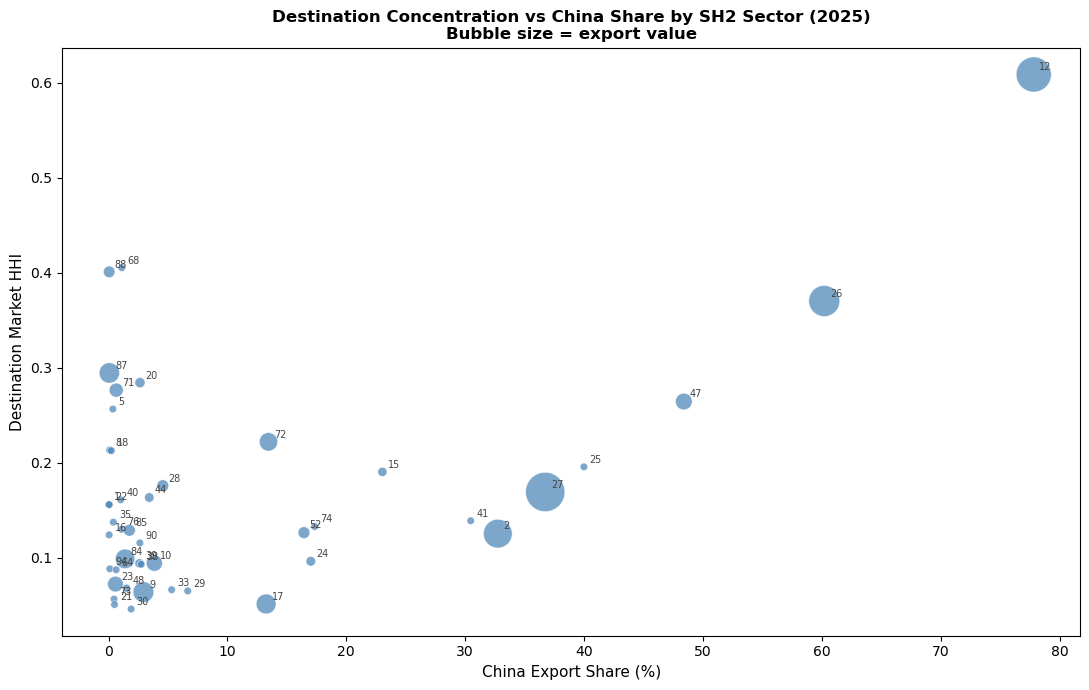

In [19]:
## Scatter: destination HHI vs China share by sector (bubbles sized by export value)

df_sc = df_dest_hhi.dropna(subset=['dest_hhi', 'china_share_pct'])

fig, ax = plt.subplots(figsize=(11, 7))
sizes = (df_sc['total_fob_bn'] / df_sc['total_fob_bn'].max() * 800).clip(lower=30)
scatter = ax.scatter(
    df_sc['china_share_pct'], df_sc['dest_hhi'],
    s=sizes, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5
)
for _, row in df_sc.iterrows():
    ax.annotate(str(row['codigo_sh2']), (row['china_share_pct'], row['dest_hhi']),
                fontsize=7, xytext=(4, 3), textcoords='offset points', color='#444444')

ax.set_xlabel('China Export Share (%)', fontsize=11)
ax.set_ylabel('Destination Market HHI', fontsize=11)
ax.set_title(
    f'Destination Concentration vs China Share by SH2 Sector ({MAX_YEAR})\n'
    f'Bubble size = export value',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output_4b_11_dest_hhi_china.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

*(Complete after running.)* Identify the sectors that sit in the upper-right quadrant — high destination HHI and high China share simultaneously. These are the highest-risk export sectors: concentrated in destination AND that destination is China. Sectors in the lower-left quadrant (low HHI, low China share) are the most geographically resilient.

#### Business Relevance

The upper-right quadrant defines Brazil's trade vulnerability concentration — the sectors where a sustained reduction in Chinese demand would have both large and hard-to-redirect impact. For risk management purposes, these sectors carry the highest structural trade disruption risk of any segment in the Brazilian export economy.

---
---

---
## 4b.12 — Export Complexity Proxy: Multi-Sector Exporting States

For each state, the number of SH2 sectors where the state accounts for more than 5% of national sector exports — a measure of the breadth of each state's competitive export presence. A state with a high count is competitive across many sectors simultaneously (high complexity); a state with a low count is a specialist in one or two sectors (low complexity, high vulnerability).

This complements the KSI (Krugman Specialisation Index) from Section 2b.2 by measuring multi-sector presence rather than deviation from the national mix.

### 4b.12.1 — Multi-Sector Competitive Presence by State

In [69]:
## For each state: count of SH2 sectors where state > 5% of national sector total

query_complexity = f"""
    WITH state_sector AS (
        SELECT
            u.sigla                   AS sg_uf,
            u.nome_estado             AS state_name,
            u.nome_regiao             AS regiao,
            sh.codigo_sh2,
            MAX(sh.descricao_sh2_ing) AS sh2_desc,
            SUM(e."VL_FOB")           AS state_sector_fob
        FROM exp e
        JOIN uf u    ON e."SG_UF_NCM" = u.sigla
        JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
        JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
        WHERE e."CO_ANO" = {MAX_YEAR}
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA', 'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA', 'REEXPORTACAO'
          )
        GROUP BY u.sigla, u.nome_estado, u.nome_regiao, sh.codigo_sh2
    ),
    national_sector AS (
        SELECT codigo_sh2, SUM(state_sector_fob) AS national_fob
        FROM state_sector
        GROUP BY codigo_sh2
    )
    SELECT
        ss.sg_uf,
        ss.state_name,
        ss.regiao,
        ss.codigo_sh2,
        ss.sh2_desc,
        ss.state_sector_fob,
        ns.national_fob,
        ROUND(100.0 * ss.state_sector_fob / NULLIF(ns.national_fob, 0), 2) AS state_pct_of_national
    FROM state_sector ss
    JOIN national_sector ns ON ss.codigo_sh2 = ns.codigo_sh2
    WHERE ns.national_fob > 100000000
    ORDER BY ss.sg_uf, state_pct_of_national DESC;
"""

df_comp = pd.read_sql(query_complexity, engine)
df_comp['regiao'] = df_comp['regiao'].map(region_name_map).fillna(df_comp['regiao'])

## Count sectors per state where state > 5% of national
multi_sector = (
    df_comp[df_comp['state_pct_of_national'] >= 5]
    .groupby(['sg_uf', 'state_name', 'regiao'])
    .agg(sectors_above_5pct=('codigo_sh2', 'count'))
    .reset_index()
    .sort_values('sectors_above_5pct', ascending=False)
)

## Styled table: state export complexity — multi-sector competitive presence

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

## Diversity tier thresholds
TIER_HIGH = 10
TIER_MID  = 5
TIER_LOW  = 2

def get_diversity_tier(n):
    if n >= TIER_HIGH:
        return 'High'
    elif n >= TIER_MID:
        return 'Moderate'
    elif n >= TIER_LOW:
        return 'Low'
    return 'Narrow'

multi_sector_display = multi_sector.rename(columns={
    'sg_uf'             : 'UF',
    'state_name'        : 'State',
    'regiao'            : 'Region',
    'sectors_above_5pct': 'Sectors > 5%',
}).copy()

multi_sector_display.insert(0, 'Rank', range(1, len(multi_sector_display) + 1))

multi_sector_display.insert(
    loc=5,
    column='Diversity',
    value=multi_sector['sectors_above_5pct'].apply(get_diversity_tier)
)

def colour_sectors(val):
    try:
        v = int(val)
    except (ValueError, TypeError):
        return ''
    if v >= TIER_HIGH:
        return f'color: {GREEN}; font-weight: 700;'
    elif v >= TIER_MID:
        return f'color: {AMBER}; font-weight: 600;'
    elif v >= TIER_LOW:
        return f'color: {RED}; font-weight: 500;'
    return f'color: {GREY_TEXT};'

def colour_diversity(val):
    if val == 'High':
        return f'color: {GREEN}; font-weight: 700;'
    elif val == 'Moderate':
        return f'color: {AMBER}; font-weight: 600;'
    elif val == 'Low':
        return f'color: {RED}; font-weight: 500;'
    return f'color: {GREY_TEXT};'

styler = (
    multi_sector_display.style
    .set_caption(
        f'Brazil — States by SH2 Sector Competitiveness, {MAX_YEAR} '
        f'| Count of sectors where state > 5% of national sector total '
        f'| High ≥ {TIER_HIGH} | Moderate ≥ {TIER_MID} | Low ≥ {TIER_LOW} | Narrow < {TIER_LOW}'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_sectors,  subset=['Sectors > 5%'])
    .map(colour_diversity, subset=['Diversity'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [   ## Rank
            ('text-align', 'center'),
            ('font-weight', '600'),
            ('color', GREY_TEXT),
            ('font-size', '12px'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [   ## UF
            ('text-align', 'center'),
            ('font-family', 'monospace'),
            ('font-weight', '700'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [   ## State name
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [   ## Region
            ('color', GREY_TEXT),
            ('font-size', '12px'),
        ]},
        {'selector': 'tbody td:nth-child(5)', 'props': [   ## Sectors > 5%
            ('text-align', 'center'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(6)', 'props': [   ## Diversity tier
            ('text-align', 'center'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

Rank,UF,State,Region,Sectors > 5%,Diversity
1,SP,São Paulo,Southeast,62,High
2,RS,Rio Grande do Sul,South,36,High
3,PR,Paraná,South,33,High
4,MG,Minas Gerais,Southeast,31,High
5,SC,Santa Catarina,South,23,High
6,RJ,Rio de Janeiro,Southeast,14,High
7,BA,Bahia,Northeast,13,High
8,GO,Goiás,Center-West,10,High
9,MT,Mato Grosso,Center-West,10,High
10,MS,Mato Grosso do Sul,Center-West,8,Moderate


#### Overview

*(Complete after running.)* Report the top 5 and bottom 5 states by sector count. São Paulo is expected to lead by a wide margin — it is the only state with established competitive presence across manufactured goods, agriculture and energy sectors simultaneously. States at the bottom of the ranking with only 1–2 sectors above the threshold are the most structurally exposed to sector-specific demand or price shocks.

#### Business Relevance

This ranking is a practical counterparty diversification index. A state with 10+ sectors above the 5% threshold offers multiple commercial entry points across different industrial profiles — a relationship in one sector can be extended to others. A state with 1–2 qualifying sectors offers no such diversification — all commercial exposure is concentrated in the same sector risk.

---
---

## 4b.13 — The Product Ladder: USD/kg Trends Over Time for Key Sectors

Annual USD/kg for Brazil's top 10 export sectors by value — tracking whether unit values have risen (value upgrading) or fallen (commoditisation) over time. A sector where export volume grows but USD/kg falls is scaling quantity at the expense of value — a structurally different dynamic from one where both volume and unit value rise simultaneously.



### 4b.13.1 — Annual USD/kg Trends for Top 10 Export Sectors

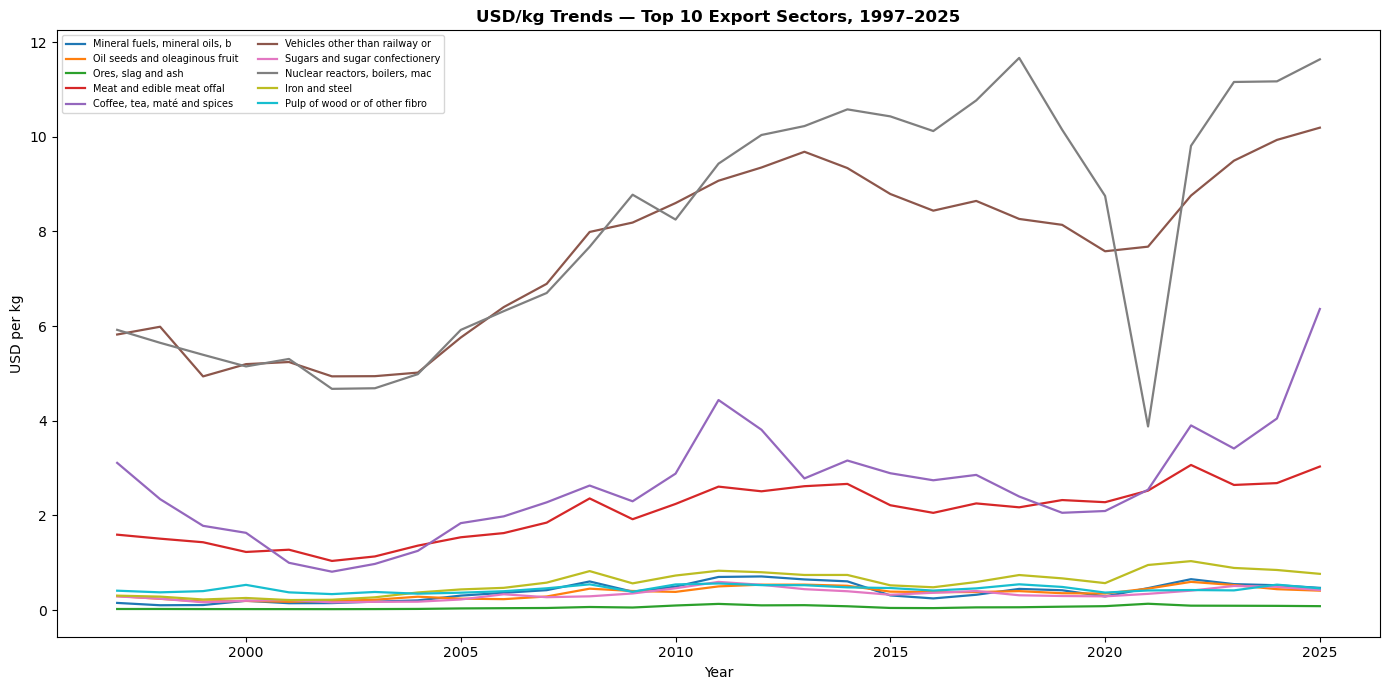

In [21]:
## Identify top 10 SH2 sectors by MAX_YEAR export value
top10_sh2 = df_growth.head(10)['codigo_sh2'].tolist()
top10_labels = dict(zip(
    df_growth.head(10)['codigo_sh2'],
    df_growth.head(10)['sh2_desc_ing'].str[:30]
))

query_uv_ts = f"""
    SELECT
        e."CO_ANO",
        sh.codigo_sh2,
        SUM(e."VL_FOB")     AS vl_fob,
        SUM(e."KG_LIQUIDO") AS kg_liq
    FROM exp e
    JOIN ncm n   ON e."CO_NCM"     = n.codigo_ncm
    JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
    WHERE e."CO_ANO" <= {MAX_YEAR}
      AND sh.codigo_sh2 IN ({','.join(str(s) for s in top10_sh2)})
      AND e."KG_LIQUIDO" > 0
    GROUP BY e."CO_ANO", sh.codigo_sh2
    ORDER BY sh.codigo_sh2, e."CO_ANO";
"""

df_uv_ts = pd.read_sql(query_uv_ts, engine)
df_uv_ts['usd_per_kg'] = df_uv_ts['vl_fob'] / df_uv_ts['kg_liq'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(14, 7))
for sh2 in top10_sh2:
    subset = df_uv_ts[df_uv_ts['codigo_sh2'] == sh2].sort_values('CO_ANO')
    ax.plot(subset['CO_ANO'], subset['usd_per_kg'], linewidth=1.6,
            label=top10_labels.get(sh2, str(sh2)))

ax.set_xlabel('Year')
ax.set_ylabel('USD per kg')
ax.set_title(f'USD/kg Trends — Top 10 Export Sectors, {MIN_YEAR}–{MAX_YEAR}', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig('output_4b_13_usdperkg_trends.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

*(Complete after running.)* Identify sectors where USD/kg has risen over the full period (genuine value upgrading) versus sectors where it has fallen (volume scaling / commoditisation). Note any sectors where USD/kg peaked around 2011 and has since declined — these may be commodity cycles rather than structural trends. Cross-reference with the Step 2c volume/price decomposition findings.

#### Business Relevance

Sectors with rising USD/kg over the full period despite growing volume represent structural value upgrading — Brazil is exporting more and receiving more per unit simultaneously. These are the sectors where Brazil's competitive position is strengthening in real terms, not just in volume. Sectors with declining USD/kg despite volume growth are becoming more commodity-like over time — a structural risk signal.

---
---

## 4b.14 — China Share vs Export Value Density: Panel Regression

Panel regression testing whether higher China export share at state level is associated with lower average export value per kilogram (USD/kg). The prior evidence (Step 2, Finding 8) establishes this relationship directionally — high China-share states are bulk commodity exporters with low USD/kg; low China-share states are value-added exporters above the national average. This section formally quantifies the magnitude and statistical reliability of that relationship across the full 1997–MAX_YEAR panel.

This section fulfils the planned addition identified as Section 2.7.3 in the Step 2 notebook.

**Method:** Pooled OLS (v1) and year fixed effects (v2), both with HC3 robust standard errors — consistent with Step 2c regression specifications. Expected direction: negative slope. V2 (year FE) is the preferred specification; v1 is reported for comparison.

**⚠️ Note:** This regression uses state-level panel data (27 geographic states × 29 years). State fixed effects are intentionally excluded — adding them would absorb the cross-sectional variation that drives the finding. Year FE controls for common time trends (commodity price cycles, global demand shocks) without eliminating the structural state-level differences that are the analytical focus.


In [53]:
## Panel data: China share and average USD/kg by state and year
## Join: SG_UF_NCM = uf.sigla | non-geographic filter via uf.nome_regiao

query_china_panel = f"""
    WITH state_totals AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            SUM(e."VL_FOB")     AS total_fob,
            SUM(e."KG_LIQUIDO") AS total_kg
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
          AND e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."SG_UF_NCM", e."CO_ANO"
    ),
    china_totals AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            SUM(e."VL_FOB") AS china_fob
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_PAIS" = {CHINA_CODE}
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
          AND e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."SG_UF_NCM", e."CO_ANO"
    )
    SELECT
        s."SG_UF_NCM"                                                   AS sg_uf,
        s."CO_ANO",
        s.total_fob,
        COALESCE(c.china_fob, 0)                                        AS china_fob,
        ROUND(
            100.0 * COALESCE(c.china_fob, 0) / NULLIF(s.total_fob, 0), 4
        )                                                               AS china_share_pct,
        ROUND(
            s.total_fob::NUMERIC / NULLIF(s.total_kg, 0), 4
        )                                                               AS usd_per_kg
    FROM state_totals s
    LEFT JOIN china_totals c
        ON s."SG_UF_NCM" = c."SG_UF_NCM" AND s."CO_ANO" = c."CO_ANO"
    WHERE s.total_fob > 0
      AND s.total_kg  > 0
    ORDER BY s."SG_UF_NCM", s."CO_ANO";
"""

df_china_panel = pd.read_sql(query_china_panel, engine)
print(f'Panel dataset: {len(df_china_panel)} state×year observations')
print(f'States: {df_china_panel["sg_uf"].nunique()} | Years: {df_china_panel["CO_ANO"].nunique()}')

## Styled preview table: panel dataset sample

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

## Show MAX_YEAR snapshot for all states as the preview — more informative than head()
df_preview = (
    df_china_panel[df_china_panel['CO_ANO'] == MAX_YEAR]
    .sort_values('china_share_pct', ascending=False)
    .reset_index(drop=True)
)

df_preview_display = df_preview[[
    'sg_uf', 'CO_ANO', 'total_fob', 'china_fob', 'china_share_pct', 'usd_per_kg'
]].rename(columns={
    'sg_uf'           : 'State',
    'CO_ANO'          : 'Year',
    'total_fob'       : 'Total Exports (USD bn)',
    'china_fob'       : 'China Exports (USD bn)',
    'china_share_pct' : 'China Share (%)',
    'usd_per_kg'      : 'USD / kg',
}).copy()

df_preview_display['Total Exports (USD bn)'] = (df_preview['total_fob'] / 1e9).apply(
    lambda x: f'${x:.2f}bn'
)
df_preview_display['China Exports (USD bn)'] = (df_preview['china_fob'] / 1e9).apply(
    lambda x: f'${x:.2f}bn'
)
df_preview_display['China Share (%)'] = df_preview['china_share_pct'].apply(
    lambda x: f'{x:.1f}%'
)
df_preview_display['USD / kg'] = df_preview['usd_per_kg'].apply(
    lambda x: f'${x:.2f}'
)

national_avg_china = (
    df_china_panel[df_china_panel['CO_ANO'] == MAX_YEAR]['china_fob'].sum()
    / df_china_panel[df_china_panel['CO_ANO'] == MAX_YEAR]['total_fob'].sum() * 100
)
national_avg_uv = (
    df_china_panel[df_china_panel['CO_ANO'] == MAX_YEAR]['total_fob'].sum()
    / df_china_panel[df_china_panel['CO_ANO'] == MAX_YEAR].apply(
        lambda r: r['total_fob'] / r['usd_per_kg'] if r['usd_per_kg'] > 0 else 0, axis=1
    ).sum()
)

def colour_china_share(val):
    try:
        v = float(val.replace('%', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= 50.0:
        return f'color: {RED}; font-weight: 700;'
    elif v >= national_avg_china:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

def colour_uv(val):
    try:
        v = float(val.replace('$', '').replace(',', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= 5.0:
        return f'color: {GREEN}; font-weight: 700;'
    elif v >= 1.0:
        return f'color: {GREEN}; font-weight: 500;'
    elif v < 0.5:
        return f'color: {RED}; font-weight: 600;'
    return f'color: {AMBER}; font-weight: 500;'

styler = (
    df_preview_display.style
    .set_caption(
        f'Panel Dataset Preview — {MAX_YEAR} Cross-Section, All States '
        f'| Sorted by China share descending '
        f'| National avg China share: {national_avg_china:.1f}%'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_china_share, subset=['China Share (%)'])
    .map(colour_uv,          subset=['USD / kg'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-weight', '600'),
            ('color', DARK_BLUE),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('text-align', 'center'),
            ('color', GREY_TEXT),
            ('font-size', '12px'),
        ]},
        {'selector': 'tbody td:nth-child(n+3)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

Panel dataset: 783 state×year observations
States: 27 | Years: 29


State,Year,Total Exports (USD bn),China Exports (USD bn),China Share (%),USD / kg
PI,2025,$1.20bn,$0.87bn,72.5%,$0.35
TO,2025,$3.05bn,$1.70bn,55.6%,$0.55
PA,2025,$24.34bn,$11.04bn,45.4%,$0.13
MS,2025,$10.75bn,$4.80bn,44.6%,$0.37
GO,2025,$13.47bn,$5.83bn,43.3%,$0.57
MT,2025,$30.19bn,$12.29bn,40.7%,$0.44
RJ,2025,$48.98bn,$18.38bn,37.5%,$0.42
MG,2025,$45.83bn,$16.06bn,35.0%,$0.22
MA,2025,$5.02bn,$1.71bn,34.1%,$0.44
RO,2025,$3.09bn,$1.02bn,33.0%,$0.71


In [52]:
## Panel data: China share and average USD/kg by state and year
## Join: SG_UF_NCM = uf.sigla | non-geographic filter via uf.nome_regiao

query_china_panel = f"""
    WITH state_totals AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            SUM(e."VL_FOB")     AS total_fob,
            SUM(e."KG_LIQUIDO") AS total_kg
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        AND e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."SG_UF_NCM", e."CO_ANO"
    ),
    china_totals AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            SUM(e."VL_FOB") AS china_fob
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_PAIS" = {CHINA_CODE}
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        AND e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."SG_UF_NCM", e."CO_ANO"
    )
    SELECT
        s."SG_UF_NCM"                                                   AS sg_uf,
        s."CO_ANO",
        s.total_fob,
        COALESCE(c.china_fob, 0)                                        AS china_fob,
        ROUND(
            100.0 * COALESCE(c.china_fob, 0) / NULLIF(s.total_fob, 0), 4
        )                                                               AS china_share_pct,
        ROUND(
            s.total_fob::NUMERIC / NULLIF(s.total_kg, 0), 4
        )                                                               AS usd_per_kg
    FROM state_totals s
    LEFT JOIN china_totals c
        ON s."SG_UF_NCM" = c."SG_UF_NCM" AND s."CO_ANO" = c."CO_ANO"
    WHERE s.total_fob > 0
      AND s.total_kg  > 0
    ORDER BY s."SG_UF_NCM", s."CO_ANO";
"""

df_china_panel = pd.read_sql(query_china_panel, engine)
print(f'Panel dataset: {len(df_china_panel)} state×year observations')
print(df_china_panel.head())

Panel dataset: 783 state×year observations
  sg_uf  CO_ANO  total_fob  china_fob  china_share_pct  usd_per_kg
0    AC    1997   206754.0        0.0           0.0000      0.4529
1    AC    1998   834242.0        0.0           0.0000      0.3605
2    AC    1999  1294459.0        0.0           0.0000      0.4280
3    AC    2000  1545989.0   170994.0          11.0605      0.3961
4    AC    2001  5815524.0   299748.0           5.1543      1.3209


In [25]:
## Panel regression: log(USD/kg) ~ China share (%) + year fixed effects
## HC3 robust standard errors throughout, consistent with Steps 2b and 2c

df_reg = df_china_panel.copy()
df_reg = df_reg[df_reg['usd_per_kg'] > 0].copy()
df_reg['log_usd_per_kg'] = np.log(df_reg['usd_per_kg'])

## v1: Pooled OLS — no year fixed effects
model_v1 = smf.ols(
    formula='log_usd_per_kg ~ china_share_pct',
    data=df_reg
).fit(cov_type='HC3')

## v2: Year fixed effects
model_v2 = smf.ols(
    formula='log_usd_per_kg ~ china_share_pct + C(CO_ANO)',
    data=df_reg
).fit(cov_type='HC3')

print('=== v1: Pooled OLS — China Share vs Log(USD/kg) ===')
print(f'N = {int(model_v1.nobs)}')
print(f'Slope (china_share_pct): {model_v1.params["china_share_pct"]:.4f}')
print(f'p-value:                 {model_v1.pvalues["china_share_pct"]:.4f}')
print(f'R²:                      {model_v1.rsquared:.4f}')

print('\n=== v2: Year FE — China Share vs Log(USD/kg) + Year Dummies ===')
print(f'N = {int(model_v2.nobs)}')
print(f'Slope (china_share_pct): {model_v2.params["china_share_pct"]:.4f}')
print(f'p-value:                 {model_v2.pvalues["china_share_pct"]:.4f}')
print(f'R²:                      {model_v2.rsquared:.4f}')

=== v1: Pooled OLS — China Share vs Log(USD/kg) ===
N = 783
Slope (china_share_pct): -0.0118
p-value:                 0.0000
R²:                      0.0353

=== v2: Year FE — China Share vs Log(USD/kg) + Year Dummies ===
N = 783
Slope (china_share_pct): -0.0236
p-value:                 0.0000
R²:                      0.1770


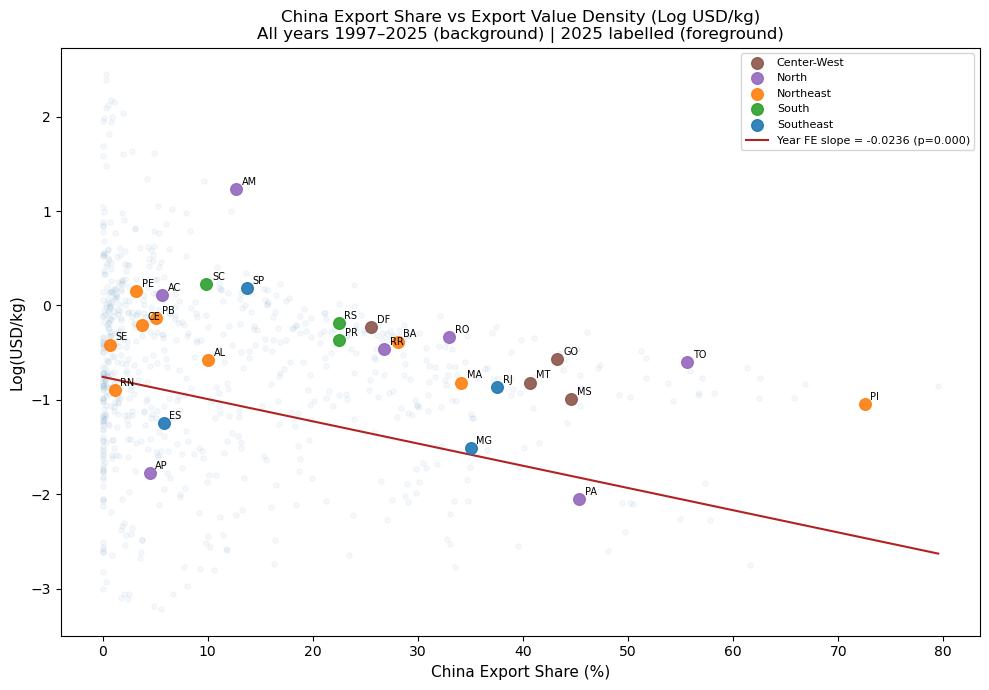

In [26]:
## Regression scatter: two-layer chart consistent with Steps 2b and 2c style
## Background: all-years faded | Foreground: MAX_YEAR labeled

region_colours = {
    'Southeast'  : '#1f77b4',
    'South'      : '#2ca02c',
    'Northeast'  : '#ff7f0e',
    'North'      : '#9467bd',
    'Center-West': '#8c564b',
}

## Add region for colour coding
df_uf_region = pd.read_sql(
    "SELECT sigla, nome_regiao FROM uf;", engine
)
df_uf_region['nome_regiao'] = df_uf_region['nome_regiao'].map(region_name_map).fillna(df_uf_region['nome_regiao'])

df_curr = df_reg[df_reg['CO_ANO'] == MAX_YEAR].merge(df_uf_region, left_on='sg_uf', right_on='sigla', how='left')
df_all  = df_reg.copy()

fig, ax = plt.subplots(figsize=(10, 7))

## Background: all years, faded
ax.scatter(
    df_all['china_share_pct'], df_all['log_usd_per_kg'],
    alpha=0.05, s=15, color='steelblue', zorder=1
)

## Foreground: MAX_YEAR, coloured by region
for region, grp in df_curr.groupby('nome_regiao'):
    ax.scatter(
        grp['china_share_pct'], grp['log_usd_per_kg'],
        alpha=0.9, s=70, color=region_colours.get(region, 'gray'),
        label=region, zorder=3
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row['sg_uf'],
            (row['china_share_pct'], row['log_usd_per_kg']),
            fontsize=7, xytext=(4, 3), textcoords='offset points', zorder=4
        )

## Regression line (v2 slope, intercept-only approximation for illustration)
x_line    = np.linspace(df_all['china_share_pct'].min(), df_all['china_share_pct'].max(), 200)
slope     = model_v2.params['china_share_pct']
intercept = model_v2.params['Intercept']
ax.plot(
    x_line, intercept + slope * x_line,
    color='firebrick', linewidth=1.5, zorder=2,
    label=f'Year FE slope = {slope:.4f} (p={model_v2.pvalues["china_share_pct"]:.3f})'
)

ax.set_xlabel('China Export Share (%)', fontsize=11)
ax.set_ylabel('Log(USD/kg)', fontsize=11)
ax.set_title(
    f'China Export Share vs Export Value Density (Log USD/kg)\n'
    f'All years 1997–{MAX_YEAR} (background) | {MAX_YEAR} labelled (foreground)',
    fontsize=12
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

#### Overview

*(Complete after running — insert slope, p-value, R², N.)* Expected direction: negative slope — states with higher China export share are associated with lower average USD/kg. If year fixed effects (v2) materially change the slope versus pooled OLS (v1), report both; if stable, v2 is preferred. A significant negative slope formally quantifies the value-density cost of China concentration.

#### Business Relevance

*(Include if the slope is statistically significant. The coefficient translates China share into an implied USD/kg penalty — directly usable as a risk quantification input for commodity-exposed state commercial profiles.)*

---
---

## 4b.15 — Product Complexity at NCM Level: State Export Basket Diversity

Shannon entropy and NCM-level HHI measure the breadth and concentration of each state's export basket at full 8-digit product granularity — complementing the SH2-level HHI from Step 2b (Section 2b.3) by capturing intra-sector product diversity.

**Why this matters:** SH2-level and NCM-level HHI can diverge significantly. A state classified as diversified at SH2 level may show high NCM concentration if each of its sectors exports a single dominant product code. The NCM-level metrics are a more precise measure of export complexity.

**Metrics computed:**
- **Shannon entropy (log₂):** Higher = more evenly distributed across NCM codes. Maximum entropy = log₂(N) where N is the number of active NCM codes.
- **NCM-level HHI:** Sum of squared NCM shares. Directly comparable to the SH2-level HHI from Section 2b.3.
- **Active NCM count:** Number of distinct 8-digit codes with non-zero exports.


In [54]:
## State-level NCM diversity metrics for MAX_YEAR
## Join: SG_UF_NCM = uf.sigla | non-geographic filter

query_ncm_diversity = f"""
    WITH state_ncm AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_NCM",
            SUM(e."VL_FOB") AS vl_fob
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" = {MAX_YEAR}
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        GROUP BY e."SG_UF_NCM", e."CO_NCM"
    ),
    state_totals AS (
        SELECT
            "SG_UF_NCM",
            SUM(vl_fob)     AS total_fob,
            COUNT("CO_NCM") AS ncm_count
        FROM state_ncm
        GROUP BY "SG_UF_NCM"
    )
    SELECT
        sn."SG_UF_NCM"                   AS sg_uf,
        u.nome_regiao                    AS regiao,
        st.total_fob,
        st.ncm_count,
        sn."CO_NCM",
        sn.vl_fob,
        sn.vl_fob::FLOAT / st.total_fob AS share
    FROM state_ncm sn
    JOIN state_totals st ON sn."SG_UF_NCM" = st."SG_UF_NCM"
    JOIN uf u ON sn."SG_UF_NCM" = u.sigla
    WHERE st.total_fob > 0;
"""

df_ncm_div = pd.read_sql(query_ncm_diversity, engine)
df_ncm_div['regiao'] = df_ncm_div['regiao'].map(region_name_map).fillna(df_ncm_div['regiao'])

def shannon_entropy(shares):
    s = shares[shares > 0]
    return -np.sum(s * np.log2(s))

def hhi(shares):
    return np.sum(shares ** 2)

diversity_metrics = (
    df_ncm_div.groupby(['sg_uf', 'regiao', 'total_fob', 'ncm_count'])['share']
    .agg(shannon=shannon_entropy, hhi_ncm=hhi)
    .reset_index()
    .sort_values('shannon', ascending=False)
)
diversity_metrics['total_fob_bn'] = diversity_metrics['total_fob'] / 1e9
## Styled table: state NCM diversity metrics
from IPython.display import display

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

REGION_COLOURS = {
    'Southeast'   : '#3a7dc9',
    'South'       : '#2eac68',
    'Center-West' : '#e07b39',
    'Northeast'   : '#9b59b6',
    'North'       : '#c0392b',
}

## Compute national reference values for colouring
national_shannon_avg = diversity_metrics['shannon'].mean()
national_hhi_avg     = diversity_metrics['hhi_ncm'].mean()

## Shannon tier thresholds (percentile-based)
shannon_p75 = diversity_metrics['shannon'].quantile(0.75)
shannon_p25 = diversity_metrics['shannon'].quantile(0.25)

## HHI tier thresholds — consistent with prior steps
HHI_HIGH = 0.25
HHI_MOD  = 0.10

df_div_display = diversity_metrics[[
    'sg_uf', 'regiao', 'total_fob_bn', 'ncm_count', 'shannon', 'hhi_ncm'
]].rename(columns={
    'sg_uf'       : 'State',
    'regiao'      : 'Region',
    'total_fob_bn': 'Exports (USD bn)',
    'ncm_count'   : 'Active NCM Codes',
    'shannon'     : 'Shannon Entropy',
    'hhi_ncm'     : 'NCM HHI',
}).copy()

df_div_display['Exports (USD bn)']  = df_div_display['Exports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_div_display['Active NCM Codes']  = df_div_display['Active NCM Codes'].apply(
    lambda x: f'{int(x):,}'
)
df_div_display['Shannon Entropy']   = df_div_display['Shannon Entropy'].apply(
    lambda x: f'{x:.3f}'
)
df_div_display['NCM HHI']           = df_div_display['NCM HHI'].apply(
    lambda x: f'{x:.4f}'
)

## Diversity tier badge derived from Shannon entropy
def get_diversity_tier(shannon):
    if shannon >= shannon_p75:
        return 'Diversified'
    elif shannon >= shannon_p25:
        return 'Moderate'
    return 'Concentrated'

df_div_display.insert(
    loc=6,
    column='Diversity',
    value=diversity_metrics['shannon'].apply(get_diversity_tier)
)

def colour_shannon(val):
    try:
        v = float(val)
    except (ValueError, AttributeError):
        return ''
    if v >= shannon_p75:
        return f'color: {GREEN}; font-weight: 700;'
    elif v >= shannon_p25:
        return f'color: {AMBER}; font-weight: 500;'
    return f'color: {RED}; font-weight: 600;'

def colour_hhi(val):
    try:
        v = float(val)
    except (ValueError, AttributeError):
        return ''
    if v >= HHI_HIGH:
        return f'color: {RED}; font-weight: 700;'
    elif v >= HHI_MOD:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

def colour_diversity(val):
    if val == 'Diversified':
        return f'color: {GREEN}; font-weight: 700;'
    elif val == 'Moderate':
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {RED}; font-weight: 600;'

def colour_region(val):
    colour = REGION_COLOURS.get(val, GREY_TEXT)
    return f'color: {colour}; font-weight: 600;'

styler = (
    df_div_display.style
    .set_caption(
        f'Brazil — State NCM Export Diversity Metrics, {MAX_YEAR} '
        f'| Sorted by Shannon entropy descending '
        f'| Diversified = top quartile | Concentrated = bottom quartile'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_region,    subset=['Region'])
    .map(colour_shannon,   subset=['Shannon Entropy'])
    .map(colour_hhi,       subset=['NCM HHI'])
    .map(colour_diversity, subset=['Diversity'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-weight', '700'),
            ('color', DARK_BLUE),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-size', '12px'),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(5)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(6)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(7)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

State,Region,Exports (USD bn),Active NCM Codes,Shannon Entropy,NCM HHI,Diversity
SP,Southeast,$71.39bn,"7,072",7.732,0.0207,Diversified
SC,South,$12.20bn,"4,356",6.890,0.0322,Diversified
RS,South,$21.53bn,"4,155",6.357,0.0489,Diversified
PR,South,$23.65bn,"4,555",6.172,0.0533,Diversified
AM,North,$0.94bn,"1,721",4.657,0.1032,Diversified
BA,Northeast,$11.63bn,"1,850",4.590,0.0871,Diversified
PE,Northeast,$2.54bn,"1,199",4.507,0.0813,Diversified
MG,Southeast,$45.83bn,"3,415",4.353,0.1436,Moderate
CE,Northeast,$2.28bn,"1,747",4.288,0.1464,Moderate
RR,North,$0.24bn,"1,449",4.079,0.1916,Moderate


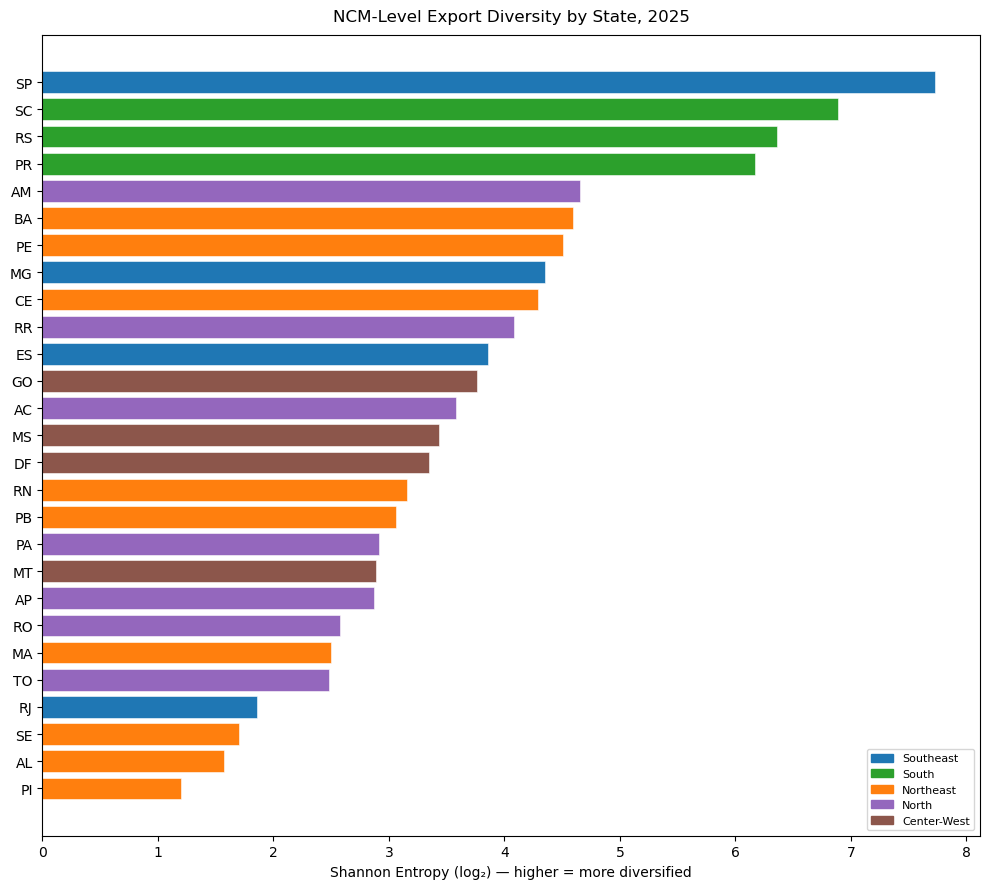

In [28]:
## Chart: NCM Shannon Entropy by State — sorted descending, coloured by region

region_colours = {
    'Southeast'  : '#1f77b4',
    'South'      : '#2ca02c',
    'Northeast'  : '#ff7f0e',
    'North'      : '#9467bd',
    'Center-West': '#8c564b',
}

df_plot  = diversity_metrics.sort_values('shannon', ascending=True)
colours  = df_plot['regiao'].map(region_colours).fillna('gray')

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(df_plot['sg_uf'], df_plot['shannon'], color=colours, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Shannon Entropy (log₂) — higher = more diversified', fontsize=10)
ax.set_title(f'NCM-Level Export Diversity by State, {MAX_YEAR}', fontsize=12, pad=10)

legend_handles = [mpatches.Patch(color=c, label=r) for r, c in region_colours.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

#### Overview

*(Complete after running.)* Compare the NCM Shannon entropy ranking against the SH2-level HHI ranking from Section 2b.3. States where the two rankings diverge are analytically significant: a state with low SH2 HHI (diverse at sector level) but low Shannon entropy (concentrated at product level) is less diversified than sector-level metrics suggest.

#### Business Relevance

NCM-level diversity is a more precise counterparty risk measure than SH2-level HHI. A state with one dominant SH2 sector but high intra-sector NCM diversity has more substitutable product risk than one locked into a single NCM code.

---
---

## 4b.16 — Export Basket Concentration Over Time: NCM-Level HHI Trends

Snapshot comparison of NCM-level product concentration across six benchmark years (1997, 2005, 2010, 2015, 2020, MAX_YEAR) — assessing whether within-state product concentration has deepened or loosened over the full period.

This section connects to two prior findings:
1. **Step 3 (Section 3.4.4):** Within-state municipality export HHI changed in both directions between 1997 and 2025. The same question is now asked at product level.
2. **Step 2c regression weakening (2010–2025 window):** Several states show their largest geographic concentration shifts in this period. Whether NCM-level HHI follows the same pattern is a cross-dimensional consistency check.

**⚠️ Query scope note:** The 131-million-row `exp` table is queried only for six snapshot years using an `IN (...)` filter — avoid full-table scans.


In [56]:
## NCM-level HHI by state for snapshot years
## Snapshot approach limits query scope on 131M row table

SNAPSHOT_YEARS = [1997, 2005, 2010, 2015, 2020, MAX_YEAR]

query_hhi_trends = f"""
    WITH state_ncm_snap AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            e."CO_NCM",
            SUM(e."VL_FOB") AS vl_fob
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" IN ({','.join(str(y) for y in SNAPSHOT_YEARS)})
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        GROUP BY e."SG_UF_NCM", e."CO_ANO", e."CO_NCM"
    ),
    state_year_total AS (
        SELECT "SG_UF_NCM", "CO_ANO", SUM(vl_fob) AS total_fob
        FROM state_ncm_snap
        GROUP BY "SG_UF_NCM", "CO_ANO"
    )
    SELECT
        sn."SG_UF_NCM"                                  AS sg_uf,
        sn."CO_ANO",
        sn."CO_NCM",
        sn.vl_fob::FLOAT / NULLIF(sy.total_fob, 0)     AS share
    FROM state_ncm_snap sn
    JOIN state_year_total sy
        ON sn."SG_UF_NCM" = sy."SG_UF_NCM"
       AND sn."CO_ANO"    = sy."CO_ANO";
"""

df_hhi_raw = pd.read_sql(query_hhi_trends, engine)

df_hhi_trends_agg = (
    df_hhi_raw.groupby(['sg_uf', 'CO_ANO'])['share']
    .apply(lambda s: np.sum(s ** 2))
    .reset_index()
    .rename(columns={'share': 'hhi_ncm'})
)

df_hhi_pivot = (
    df_hhi_trends_agg
    .pivot(index='sg_uf', columns='CO_ANO', values='hhi_ncm')
    .round(4)
)

df_hhi_pivot['Δ 1997–2025'] = (df_hhi_pivot[MAX_YEAR] - df_hhi_pivot[1997]).round(4)
df_hhi_pivot = df_hhi_pivot.sort_values('Δ 1997–2025', ascending=True)

## Styled table: NCM-level HHI trends across snapshot years

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'

HHI_HIGH = 0.25
HHI_MOD  = 0.10

df_hhi_display = df_hhi_pivot.reset_index().rename(columns={'sg_uf': 'State'}).copy()

## Rename snapshot year columns to strings for display
year_cols = [str(y) for y in SNAPSHOT_YEARS]
df_hhi_display.columns = (
    ['State'] + year_cols + ['Δ 1997–2025']
)

## Format snapshot year columns
for col in year_cols:
    df_hhi_display[col] = df_hhi_display[col].apply(
        lambda x: f'{x:.4f}' if pd.notna(x) else '—'
    )

## Format delta column with explicit sign
df_hhi_display['Δ 1997–2025'] = df_hhi_display['Δ 1997–2025'].apply(
    lambda x: f'{x:+.4f}' if pd.notna(x) else '—'
)

## HHI value colouring — applied to all snapshot year cells
def colour_hhi_val(val):
    if val == '—':
        return f'color: {GREY_TEXT};'
    try:
        v = float(val)
    except (ValueError, AttributeError):
        return ''
    if v >= HHI_HIGH:
        return f'color: {RED}; font-weight: 700;'
    elif v >= HHI_MOD:
        return f'color: {AMBER}; font-weight: 600;'
    return f'color: {GREEN}; font-weight: 500;'

## Delta colouring — positive = more concentrated (red), negative = more diversified (green)
def colour_delta(val):
    if val == '—':
        return f'color: {GREY_TEXT};'
    try:
        v = float(val)
    except (ValueError, AttributeError):
        return ''
    if v > 0.05:
        return f'color: {RED}; font-weight: 700;'
    elif v > 0.01:
        return f'color: {AMBER}; font-weight: 600;'
    elif v < -0.05:
        return f'color: {GREEN}; font-weight: 700;'
    elif v < -0.01:
        return f'color: {GREEN}; font-weight: 500;'
    return f'color: {GREY_TEXT};'

styler = (
    df_hhi_display.style
    .set_caption(
        f'Brazil — NCM-Level Export HHI by State, Snapshot Years '
        f'({", ".join(str(y) for y in SNAPSHOT_YEARS)}) '
        f'| Sorted by 1997–{MAX_YEAR} change ascending '
        f'| HHI: Concentrated ≥ 0.25 | Moderate 0.10–0.25 | Distributed < 0.10 '
        f'| Δ: positive = more concentrated, negative = more diversified'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'right',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_hhi_val, subset=year_cols)
    .map(colour_delta,   subset=['Δ 1997–2025'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
            ('text-align', 'right'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-weight', '700'),
            ('color', DARK_BLUE),
            ('text-align', 'center'),
        ]},
        ## Snapshot year columns
        {'selector': 'tbody td:nth-child(n+2):nth-child(-n+7)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        ## Delta column — last column, visually separated
        {'selector': 'tbody td:last-child', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
            ('border-left', f'2px solid {LIGHT_BLUE}'),
            ('background-color', '#f9f9f9'),
        ]},
        {'selector': 'thead th:last-child', 'props': [
            ('border-left', f'2px solid {MID_BLUE}'),
            ('background-color', MID_BLUE),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

State,1997,2005,2010,2015,2020,2025,Δ 1997–2025
DF,0.4472,0.2787,0.2911,0.2753,0.2335,0.1611,-0.2861
RR,0.4150,0.2078,0.2424,0.6010,0.0866,0.1916,-0.2234
MA,0.3935,0.1844,0.1805,0.2397,0.1935,0.2647,-0.1288
MS,0.2855,0.1079,0.1010,0.1528,0.1775,0.1650,-0.1205
ES,0.2317,0.2438,0.3343,0.1866,0.1100,0.1186,-0.1131
MT,0.3286,0.3081,0.2200,0.2489,0.2461,0.2337,-0.0949
AC,0.2191,0.2017,0.2130,0.4485,0.0590,0.1260,-0.0931
PE,0.1683,0.0521,0.1297,0.0624,0.1018,0.0813,-0.0870
AL,0.5364,0.3470,0.6507,0.4825,0.7727,0.4617,-0.0747
PR,0.0976,0.0338,0.0530,0.0664,0.1024,0.0533,-0.0443


#### Overview

*(Complete after running.)* Identify which states show the largest NCM-level HHI changes across the six snapshot years. Cross-reference against municipality-level HHI changes from Step 3, Section 3.4.4 — if geographic and product concentration moved in the same direction over the same period, that is a stronger structural signal than either dimension alone.

---
---


## 4b.17 — China Share by National Export Sector

China's share of each major SH2 export sector — confirming which product categories drive the Brazil-China relationship and establishing the sector-level foundation for the state-level China dependency patterns identified in Step 2 (Section 2.7).

**Context:** The national average China share is approximately 28.7% (Step 1). That average conceals extreme variation by sector. The commodity-sector concentration hypothesis — soybeans, iron ore and raw materials at 60–80% China share; manufactured goods at < 5% — was established directionally in Step 2 but not confirmed with national sector-level data.

**Join path:** `exp.CO_NCM` → `ncm.codigo_ncm` → `ncm.codigo_sh6` → `ncm_sh.codigo_sh6` → `ncm_sh.descricao_sh2`


In [57]:
## National China share by SH2 sector
## Join ncm → ncm_sh via codigo_sh6 to get descricao_sh2

query_china_sector = f"""
    WITH sector_totals AS (
        SELECT
            n.codigo_sh6,
            SUM(e."VL_FOB") AS total_fob
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        WHERE e."CO_ANO" = {MAX_YEAR}
        GROUP BY n.codigo_sh6
    ),
    china_by_sector AS (
        SELECT
            n.codigo_sh6,
            SUM(e."VL_FOB") AS china_fob
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        WHERE e."CO_ANO"  = {MAX_YEAR}
          AND e."CO_PAIS" = {CHINA_CODE}
        GROUP BY n.codigo_sh6
    ),
    sh2_agg AS (
        SELECT
            sh.codigo_sh2,
            sh.descricao_sh2,
            SUM(st.total_fob)              AS total_fob,
            SUM(COALESCE(cs.china_fob, 0)) AS china_fob
        FROM sector_totals st
        LEFT JOIN china_by_sector cs ON st.codigo_sh6 = cs.codigo_sh6
        LEFT JOIN ncm_sh sh          ON st.codigo_sh6 = sh.codigo_sh6
        GROUP BY sh.codigo_sh2, sh.descricao_sh2
    )
    SELECT
        codigo_sh2,
        descricao_sh2,
        total_fob,
        china_fob,
        ROUND(100.0 * china_fob / NULLIF(total_fob, 0), 2) AS china_share_pct
    FROM sh2_agg
    ORDER BY total_fob DESC
    LIMIT 30;
"""

df_china_sector = pd.read_sql(query_china_sector, engine)
df_china_sector['total_fob_bn'] = df_china_sector['total_fob'] / 1e9
df_china_sector['china_fob_bn'] = df_china_sector['china_fob'] / 1e9

## National weighted average China share across all sectors
national_china_avg = (
    df_china_sector['china_fob'].sum()
    / df_china_sector['total_fob'].sum() * 100
)
print(f'National China share by SH2 export sector, {MAX_YEAR}')
print(f'National weighted average China share: {national_china_avg:.1f}%')

## Styled table: national China share by SH2 sector

DARK_BLUE  = '#1a2e44'
MID_BLUE   = '#2c4a6e'
LIGHT_BLUE = '#e8f0f7'
WHITE      = '#ffffff'
STRIPE     = '#f4f7fa'
GREEN      = '#1a7a4a'
AMBER      = '#b7660a'
RED        = '#c0392b'
GREY_TEXT  = '#555555'
CHINA_RED  = '#c0392b'

## China share thresholds
CHINA_DOMINANT = 50.0
CHINA_HIGH     = national_china_avg   ## above national average = elevated
CHINA_LOW      = 10.0

df_cs_display = df_china_sector[[
    'codigo_sh2', 'descricao_sh2', 'total_fob_bn', 'china_fob_bn', 'china_share_pct'
]].rename(columns={
    'codigo_sh2'     : 'SH2',
    'descricao_sh2'  : 'Sector (PT)',
    'total_fob_bn'   : 'Total Exports (USD bn)',
    'china_fob_bn'   : 'China Exports (USD bn)',
    'china_share_pct': 'China Share (%)',
}).copy()

df_cs_display['Total Exports (USD bn)'] = df_cs_display['Total Exports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_cs_display['China Exports (USD bn)'] = df_cs_display['China Exports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_cs_display['China Share (%)'] = df_cs_display['China Share (%)'].apply(
    lambda x: f'{x:.1f}%' if pd.notna(x) else '—'
)

## China exposure badge
def get_china_exposure(share):
    if share >= CHINA_DOMINANT:
        return 'Critical'
    elif share >= CHINA_HIGH:
        return 'Elevated'
    elif share >= CHINA_LOW:
        return 'Moderate'
    return 'Low'

df_cs_display.insert(
    loc=5,
    column='China Exposure',
    value=df_china_sector['china_share_pct'].apply(get_china_exposure)
)

def colour_china_share(val):
    if val == '—':
        return f'color: {GREY_TEXT};'
    try:
        v = float(val.replace('%', ''))
    except (ValueError, AttributeError):
        return ''
    if v >= CHINA_DOMINANT:
        return f'color: {RED}; font-weight: 700;'
    elif v >= CHINA_HIGH:
        return f'color: {AMBER}; font-weight: 600;'
    elif v < CHINA_LOW:
        return f'color: {GREEN}; font-weight: 500;'
    return f'color: {GREY_TEXT};'

def colour_exposure(val):
    if val == 'Critical':
        return f'color: {RED}; font-weight: 700;'
    elif val == 'Elevated':
        return f'color: {AMBER}; font-weight: 600;'
    elif val == 'Moderate':
        return f'color: {GREY_TEXT}; font-weight: 500;'
    return f'color: {GREEN}; font-weight: 500;'

styler = (
    df_cs_display.style
    .set_caption(
        f'Brazil — China Export Share by SH2 Sector, {MAX_YEAR} '
        f'| Top 30 sectors by total value '
        f'| National avg China share: {national_china_avg:.1f}% '
        f'| Elevated = above national average'
    )
    .set_properties(**{
        'font-family'  : 'Helvetica Neue, Arial, sans-serif',
        'font-size'    : '13px',
        'text-align'   : 'left',
        'padding'      : '8px 14px',
        'border-bottom': f'1px solid {LIGHT_BLUE}',
    })
    .map(colour_china_share, subset=['China Share (%)'])
    .map(colour_exposure,    subset=['China Exposure'])
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', '700'),
            ('font-family', 'Helvetica Neue, Arial, sans-serif'),
            ('color', DARK_BLUE),
            ('padding', '0 0 10px 0'),
            ('text-align', 'left'),
        ]},
        {'selector': 'thead th', 'props': [
            ('background-color', DARK_BLUE),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('letter-spacing', '0.04em'),
            ('padding', '10px 14px'),
            ('border', 'none'),
        ]},
        {'selector': 'thead tr:last-child th', 'props': [
            ('border-bottom', f'2px solid {MID_BLUE}'),
        ]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [
            ('background-color', WHITE),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', STRIPE),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', LIGHT_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(1)', 'props': [
            ('font-family', 'monospace'),
            ('font-size', '12px'),
            ('color', GREY_TEXT),
            ('text-align', 'center'),
        ]},
        {'selector': 'tbody td:nth-child(2)', 'props': [
            ('font-weight', '500'),
            ('color', DARK_BLUE),
        ]},
        {'selector': 'tbody td:nth-child(3)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(4)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
        ]},
        {'selector': 'tbody td:nth-child(5)', 'props': [
            ('text-align', 'right'),
            ('font-variant-numeric', 'tabular-nums'),
            ('border-right', f'1px solid {LIGHT_BLUE}'),
        ]},
        {'selector': 'tbody td:nth-child(6)', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', f'1px solid {LIGHT_BLUE}'),
            ('border-radius', '6px'),
            ('overflow', 'hidden'),
        ]},
    ])
    .hide(axis='index')
)

display(styler)

National China share by SH2 export sector, 2025
National weighted average China share: 30.5%


SH2,Sector (PT),Total Exports (USD bn),China Exports (USD bn),China Share (%),China Exposure
27,"Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais",$55.96bn,$20.55bn,36.7%,Elevated
12,"Sementes e frutos oleaginosos; grãos, sementes e frutos diversos; plantas industriais ou medicinais; palhas e forragens",$44.67bn,$34.76bn,77.8%,Critical
26,"Minerios, escórias e cinzas",$34.89bn,$21.00bn,60.2%,Critical
2,"Carnes e miudezas, comestíveis",$29.98bn,$9.81bn,32.7%,Elevated
9,"Café, chá, mate e especiarias",$15.65bn,$0.46bn,2.9%,Low
87,"Veículos automóveis, tratores, ciclos e outros veículos terrestres, suas partes e acessórios",$15.08bn,$0.01bn,0.1%,Low
17,Açúcares e produtos de confeitaria,$14.34bn,$1.90bn,13.2%,Moderate
84,"Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes",$13.89bn,$0.19bn,1.4%,Low
72,"Ferro fundido, ferro e aço",$12.35bn,$1.66bn,13.4%,Moderate
47,Pastas de madeira ou de outras matérias fibrosas celulósicas; papel ou cartão para reciclar (desperdícios e aparas).,$10.17bn,$4.92bn,48.4%,Elevated


#### Overview

*(Complete after running.)* Report China share for all major export sectors. Expected pattern: soybeans, iron ore and copper at 60–80%; manufactured goods (vehicles, aircraft, machinery) at < 5%. The sector-level China share table is the national counterpart to the state-level analysis in Section 2.7 — it shows which products, not which states, drive the Brazil-China relationship.

#### Business Relevance

Sectors above 50% China share carry concentrated destination risk. Any sustained reduction in Chinese demand flows directly to those sectors' export volumes and FOB values with limited short-term diversion capacity.

---
---


## 4b.18 — Key Findings

*(Complete after all sections above are executed. Structure: numbered findings, directly traceable to data, no speculation. Cross-reference against Step 4A findings where open investigations have been resolved. Flag any mechanisms that remain unconfirmed with ⚠️.)*
